**1st output. : Zig Zag motion**

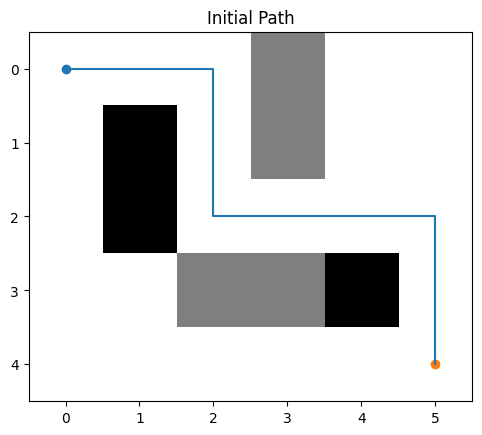

Adding dynamic obstacle...


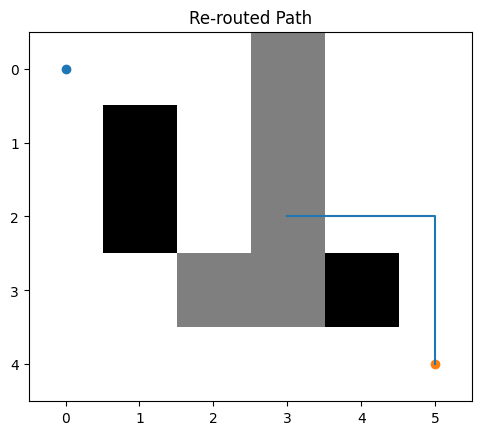

In [ ]:
import heapq
import numpy as np
import matplotlib.pyplot as plt


# GRID SETUP
grid = np.array([
    [0, 0, 0, 1, 0, 0],
    [0, 2, 0, 1, 0, 0],
    [0, 2, 0, 0, 0, 0],
    [0, 0, 1, 1, 2, 0],
    [0, 0, 0, 0, 0, 0]
])

ROWS, COLS = grid.shape

start = (0, 0)
goal = (4, 5)

terrain_cost = {
    0: 1,   # free
    2: 5    # high cost
}


# HEURISTIC (Manhattan)
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# GET NEIGHBORS
def get_neighbors(node):
    directions = [(0,1),(1,0),(0,-1),(-1,0)]
    neighbors = []

    for d in directions:
        r = node[0] + d[0]
        c = node[1] + d[1]

        if 0 <= r < ROWS and 0 <= c < COLS:
            if grid[r][c] != 1 and grid[r][c] != 3:
                neighbors.append((r, c))

    return neighbors

# WEIGHTED A* ALGORITHM
def weighted_astar(start, goal, w=1.5):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            # reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current):
            cell_type = grid[neighbor]
            cost = terrain_cost.get(cell_type, 1)

            tentative_g = g_score[current] + cost

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g

                f_score = tentative_g + w * heuristic(neighbor, goal)

                heapq.heappush(open_set, (f_score, neighbor))
                came_from[neighbor] = current

    return None

# VISUALIZATION

def visualize(grid, path, title="Path"):
    plt.imshow(grid, cmap='gray_r')

    if path:
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        plt.plot(x, y)

    plt.scatter(start[1], start[0])
    plt.scatter(goal[1], goal[0])

    plt.title(title)
    plt.show()


# INITIAL PATH

path = weighted_astar(start, goal)
visualize(grid, path, "Initial Path")


# DYNAMIC OBSTACLE (RE-ROUTING)

print("Adding dynamic obstacle...")

grid[2][3] = 1  # new obstacle appears

# Assume drone is midway
current_position = path[len(path)//2]

new_path = weighted_astar(current_position, goal)

visualize(grid, new_path, "Re-routed Path")

Path found: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (3, 5), (3, 6), (4, 6), (5, 6), (6, 6)]


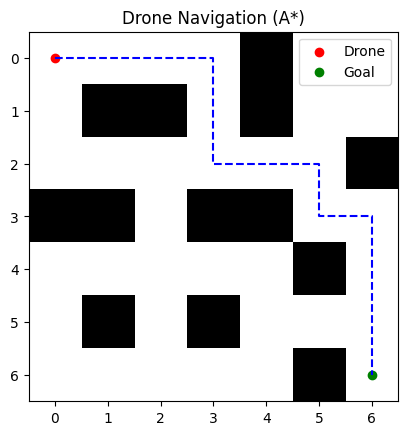

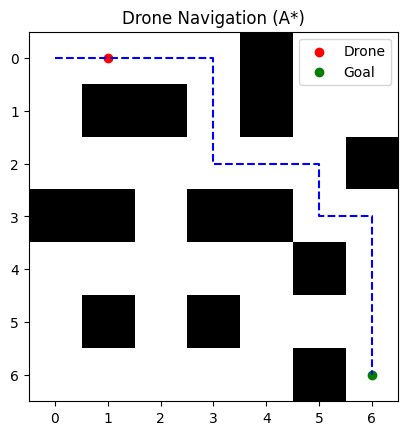

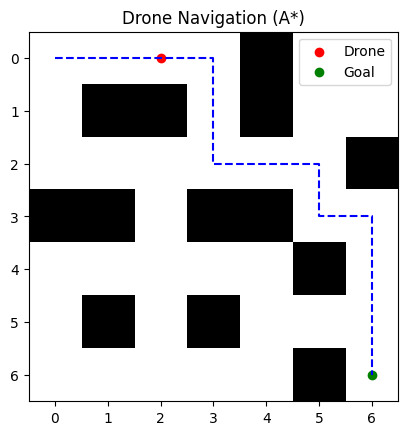

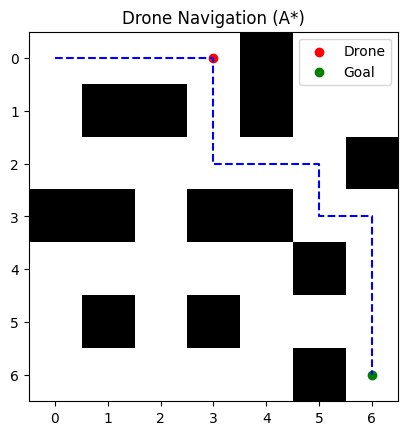

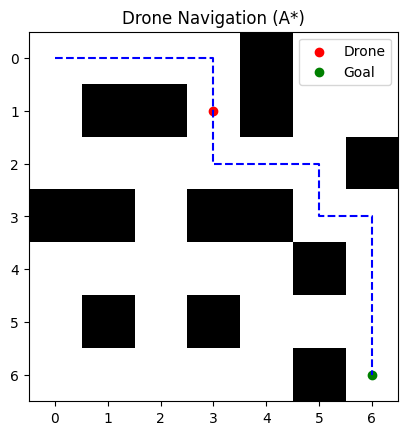

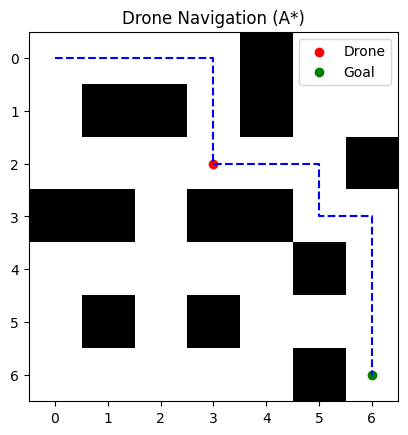

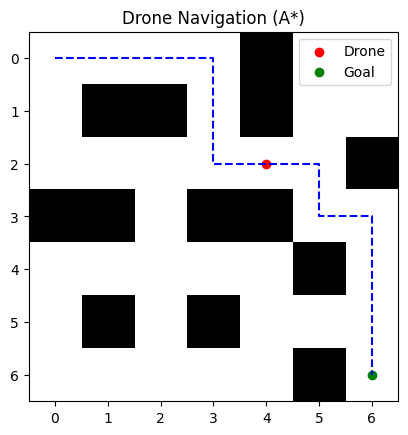

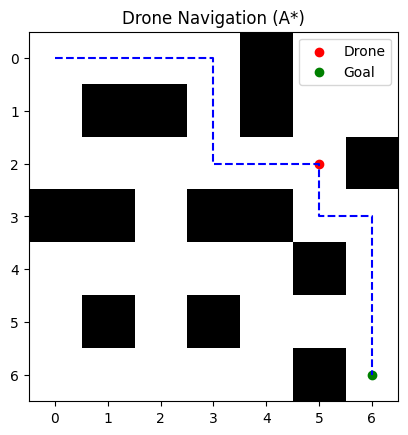

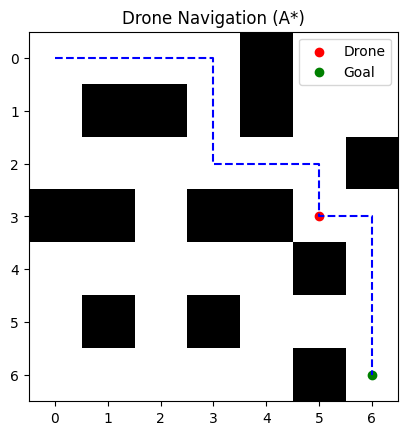

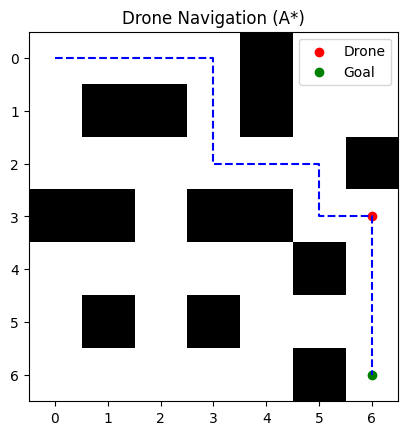

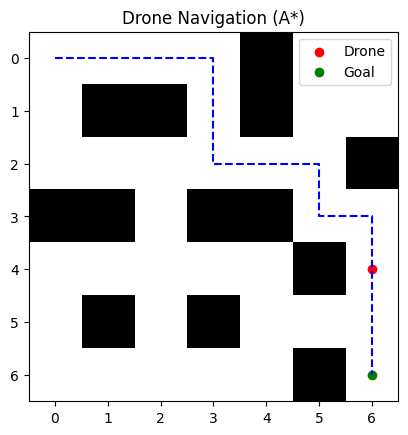

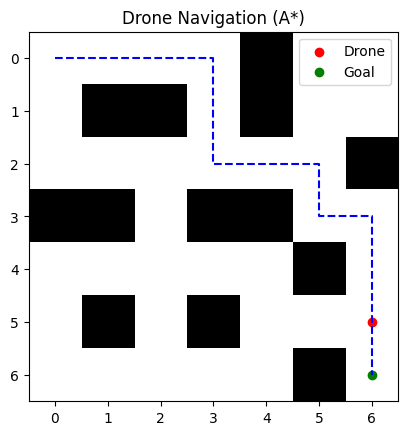

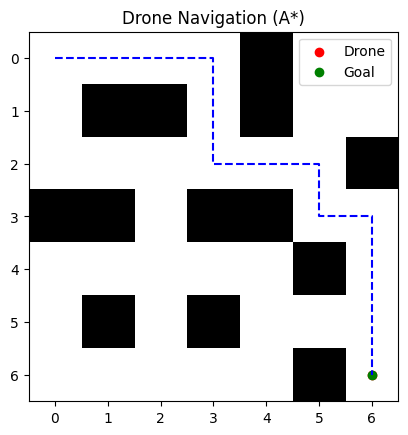

In [ ]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
import time


# GRID SETUP
grid = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0]
])

ROWS, COLS = grid.shape

start = (0, 0)
goal = (6, 6)


# HEURISTIC (Manhattan)

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# NEIGHBORS
def get_neighbors(node):
    directions = [(0,1),(1,0),(0,-1),(-1,0)]
    neighbors = []

    for d in directions:
        r = node[0] + d[0]
        c = node[1] + d[1]

        if 0 <= r < ROWS and 0 <= c < COLS:
            if grid[r][c] != 1:
                neighbors.append((r, c))

    return neighbors

# A* ALGORITHM
def astar(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            # reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current):
            temp_g = g_score[current] + 1

            if neighbor not in g_score or temp_g < g_score[neighbor]:
                g_score[neighbor] = temp_g
                f_score = temp_g + heuristic(neighbor, goal)

                heapq.heappush(open_set, (f_score, neighbor))
                came_from[neighbor] = current

    return None

# ANIMATION
def animate(grid, path):
    plt.figure()

    for i in range(len(path)):
        plt.clf()
        plt.imshow(grid, cmap='gray_r')

        # draw path
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        plt.plot(x, y, 'b--')

        # drone position
        plt.scatter(path[i][1], path[i][0], c='red', label="Drone")

        # goal
        plt.scatter(goal[1], goal[0], c='green', label="Goal")

        plt.legend()
        plt.title("Drone Navigation (A*)")
        plt.pause(0.3)

    plt.show()

# -----------------------------
# RUN
# -----------------------------
path = astar(start, goal)

if path:
    print("Path found:", path)
    animate(grid, path)
else:
    print("No path found!")

**code with euclidian distance and path smoothening.**

Path found: [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (3, 2), (3, 3), (4, 3), (4, 4)]


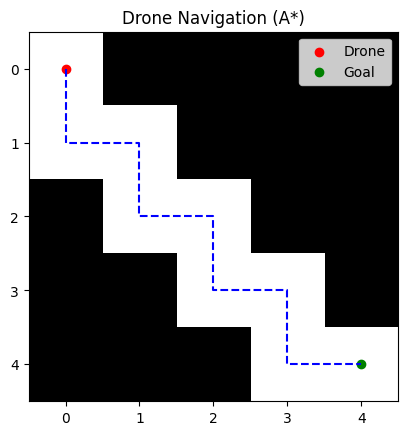

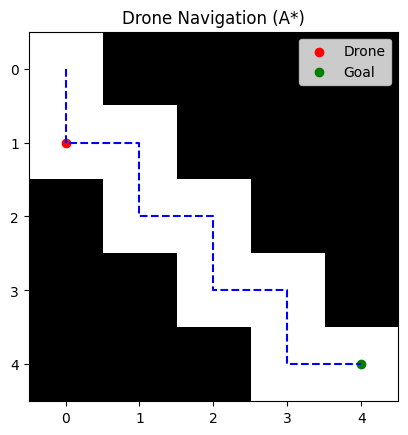

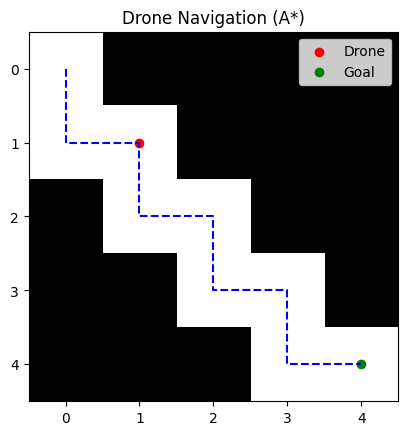

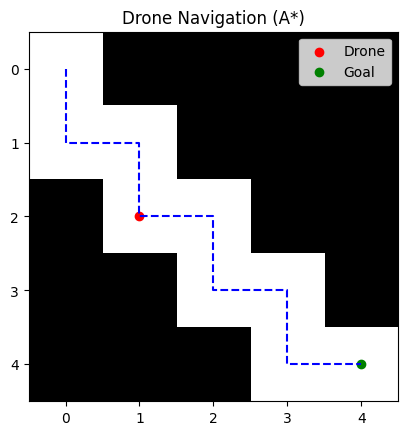

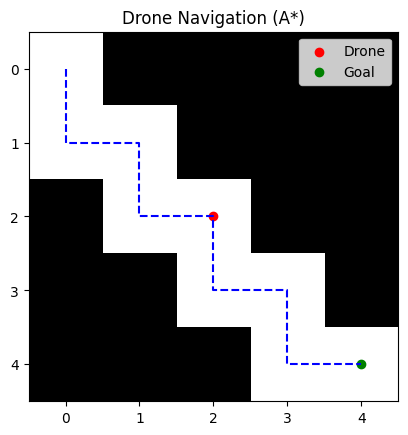

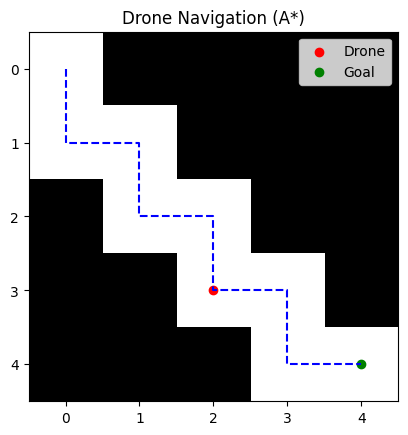

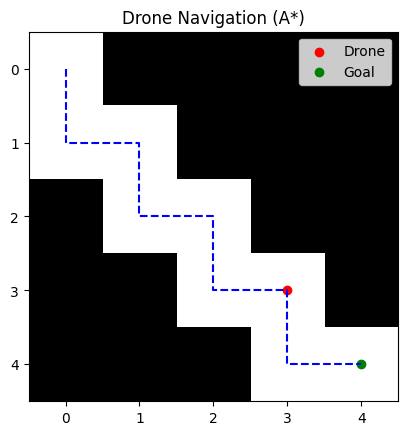

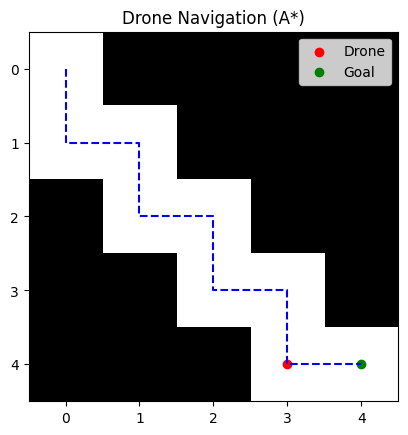

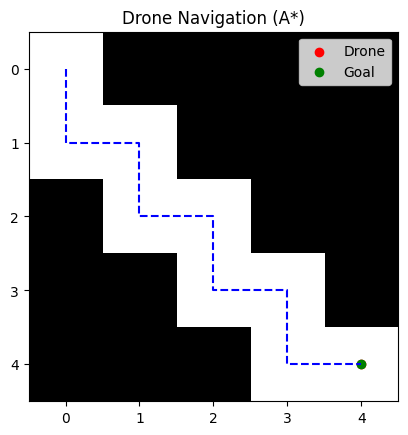

In [ ]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
import time

# -----------------------------
# GRID SETUP
# -----------------------------
# grid = np.array([
#     [0, 0, 0, 0, 1, 0, 0],
#     [0, 1, 1, 0, 1, 0, 0],
#     [0, 0, 0, 0, 0, 0, 1],
#     [1, 1, 0, 1, 1, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0],
#     [0, 1, 0, 1, 0, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0]
# ])

grid = np.array([
 [0, 1, 1, 1, 1],
 [0, 0, 1, 1, 1],
 [1, 0, 0, 1, 1],
 [1, 1, 0, 0, 1],
 [1, 1, 1, 0, 0]
])

ROWS, COLS = grid.shape

start = (0, 0)
goal = (4, 4)

# grid [2][2] = 1
# grid [3][3] = 1


# HEURISTIC (Manhattan)
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# NEIGHBORS (Updated to include diagonal movement and corner checks)
def get_neighbors(node):
    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    neighbors = []

    for d in directions:
        r = node[0] + d[0]
        c = node[1] + d[1]

        if 0 <= r < ROWS and 0 <= c < COLS:

            # obstacle check
            if grid[r][c] == 1:
                continue

            # 🔥 CORNER CUTTING CHECK
            if abs(d[0]) == 1 and abs(d[1]) == 1:
                if grid[node[0]][c] == 1 or grid[r][node[1]] == 1:
                    continue

            neighbors.append((r, c))

    return neighbors


# A* ALGORITHM
def astar(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            # reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current):
            # Cost for diagonal move is sqrt(2), for cardinal it's 1.
            # For simplicity, we can use 1 for all moves in grid-based A* if we just care about number of steps,
            # or adjust for Euclidean distance if needed. Here, keeping it simple as 1.
            move_cost = 1 if abs(neighbor[0] - current[0]) + abs(neighbor[1] - current[1]) == 1 else 1.414 # Approximate sqrt(2)
            temp_g = g_score[current] + move_cost

            if neighbor not in g_score or temp_g < g_score[neighbor]:
                g_score[neighbor] = temp_g
                f_score = temp_g + heuristic(neighbor, goal)

                heapq.heappush(open_set, (f_score, neighbor))
                came_from[neighbor] = current

    return None

def is_clear(grid, p1, p2):
    # simple line check
    x1, y1 = p1
    x2, y2 = p2

    steps = max(abs(x2-x1), abs(y2-y1))

    # Avoid division by zero if steps is 0 (p1 == p2)
    if steps == 0:
        return grid[x1][y1] != 1

    for i in range(steps + 1):
        x = int(x1 + (x2-x1)*i/steps)
        y = int(y1 + (y2-y1)*i/steps)

        if grid[x][y] == 1:
            return False
    return True


def smooth_path(grid, path):
    smooth = [path[0]]

    i = 0
    while i < len(path)-1:
        j = len(path)-1

        while j > i:
            if is_clear(grid, path[i], path[j]):
                smooth.append(path[j])
                i = j
                break
            j -= 1

    return smooth

# -----------------------------
# ANIMATION
# -----------------------------
def animate(grid, path):
    plt.figure()

    for i in range(len(path)):
        plt.clf()
        plt.imshow(grid, cmap='gray_r')

        # draw path
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        plt.plot(x, y, 'b--')

        # drone position
        plt.scatter(path[i][1], path[i][0], c='red', label="Drone")

        # goal
        plt.scatter(goal[1], goal[0], c='green', label="Goal")

        plt.legend()
        plt.title("Drone Navigation (A*)")
        plt.pause(0.3)

    plt.show()


# -----------------------------
# RUN
# -----------------------------
path = astar(start, goal)

if path:
    print("Path found:", path)
    animate(grid, path)
else:
    print("No path found!")

**below one is the 1st code with diagonal movement. But the problem is that it does not avoide the obsticles.**

Path found: [(0, 0), (5, 4), (6, 6)]


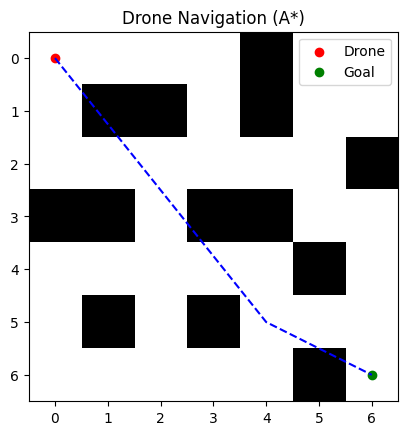

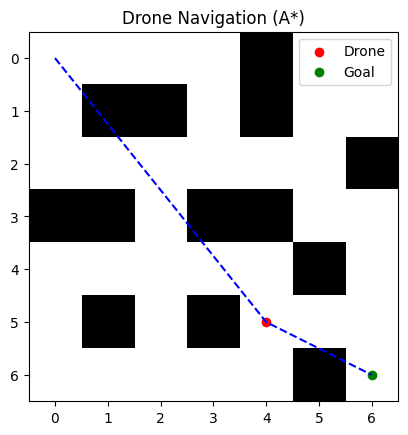

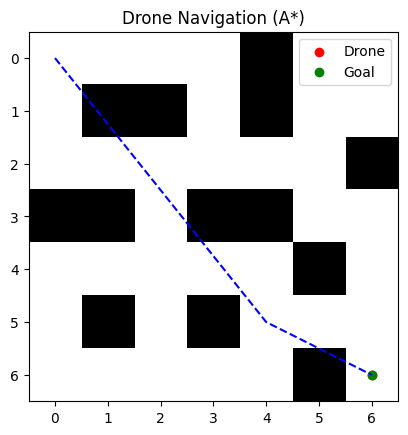

In [ ]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
import time
import math

# -----------------------------
# GRID SETUP
# -----------------------------
grid = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0]
])

# grid = np.array([
#  [0, 1, 1, 1, 1],
#  [0, 0, 1, 1, 1],
#  [1, 0, 0, 1, 1],
#  [1, 1, 0, 0, 1],
#  [1, 1, 1, 0, 0]
# ])

# grid = np.zeros((5,5))

ROWS, COLS = grid.shape

start = (0, 0)
goal = (6, 6)

# grid [2][2] = 1
# grid [3][3] = 1

# -----------------------------
# HEURISTIC (Manhattan)
# -----------------------------

#def heuristic(a, b):
#    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def heuristic(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# -----------------------------
# NEIGHBORS (Updated to include diagonal movement and corner checks)
# -----------------------------
def get_neighbors(node):
    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    neighbors = []

    for d in directions:
        r = node[0] + d[0]
        c = node[1] + d[1]

        if 0 <= r < ROWS and 0 <= c < COLS:

            # obstacle check
            if grid[r][c] == 1:
                continue

            # 🔥 CORNER CUTTING CHECK
            if abs(d[0]) == 1 and abs(d[1]) == 1:
                if grid[node[0]][c] == 1 or grid[r][node[1]] == 1:
                    continue

            neighbors.append((r, c))

    return neighbors

# -----------------------------
# A* ALGORITHM
# -----------------------------
def astar(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            # reconstruct path
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current):
            # Cost for diagonal move is sqrt(2), for cardinal it's 1.
            # For simplicity, we can use 1 for all moves in grid-based A* if we just care about number of steps,
            # or adjust for Euclidean distance if needed. Here, keeping it simple as 1.
            move_cost = 1 if abs(neighbor[0] - current[0]) + abs(neighbor[1] - current[1]) == 1 else 1.414 # Approximate sqrt(2)
            temp_g = g_score[current] + move_cost

            if neighbor not in g_score or temp_g < g_score[neighbor]:
                g_score[neighbor] = temp_g
                f_score = temp_g + heuristic(neighbor, goal)

                heapq.heappush(open_set, (f_score, neighbor))
                came_from[neighbor] = current

    return None

def is_clear(grid, p1, p2):
    # simple line check
    x1, y1 = p1
    x2, y2 = p2

    steps = max(abs(x2-x1), abs(y2-y1))

    # Avoid division by zero if steps is 0 (p1 == p2)
    if steps == 0:
        return grid[x1][y1] != 1

    for i in range(steps + 1):
        x = int(x1 + (x2-x1)*i/steps)
        y = int(y1 + (y2-y1)*i/steps)

        if grid[x][y] == 1:
            return False
    return True


def smooth_path(grid, path):
    smooth = [path[0]]

    i = 0
    while i < len(path)-1:
        j = len(path)-1

        while j > i:
            if is_clear(grid, path[i], path[j]):
                smooth.append(path[j])
                i = j
                break
            j -= 1

    return smooth

# -----------------------------
# ANIMATION
# -----------------------------
def animate(grid, path):
    plt.figure()

    for i in range(len(path)):
        plt.clf()
        plt.imshow(grid, cmap='gray_r')

        # draw path
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        plt.plot(x, y, 'b--')

        # drone position
        plt.scatter(path[i][1], path[i][0], c='red', label="Drone")

        # goal
        plt.scatter(goal[1], goal[0], c='green', label="Goal")

        plt.legend()
        plt.title("Drone Navigation (A*)")
        plt.pause(0.3)

    plt.show()


# -----------------------------
# RUN
# -----------------------------
#path = astar(start, goal)

path = astar(start, goal)

if path:
    path = smooth_path(grid, path)

    print("Path found:", path)
    animate(grid, path)
else:
    print("No path found!")


Original Path: [(0, 0), (1, 1), (2, 1), (3, 2)]
Smoothed Path: [(0, 0), (3, 2)]


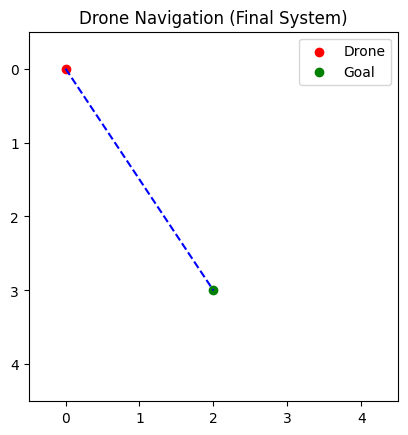

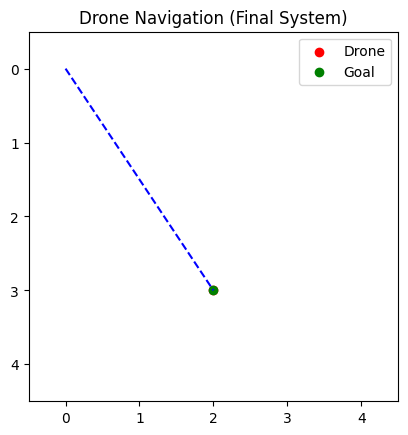

In [ ]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# GRID SETUP
# -----------------------------
# grid = np.array([
#     [0, 0, 0, 0, 1, 0, 0],
#     [0, 1, 1, 0, 1, 0, 0],
#     [0, 0, 0, 0, 0, 0, 1],
#     [1, 1, 0, 1, 1, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0],
#     [0, 1, 0, 1, 0, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0]
# ])


# grid = np.array([
#     [0, 0, 0, 0, 1, 0, 0],
#     [0, 1, 1, 0, 1, 0, 0],
#     [0, 0, 0, 0, 0, 0, 1],
#     [1, 1, 0, 1, 1, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0],
#     [0, 1, 0, 1, 0, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0]
# ])

grid = np.zeros((5,5))

ROWS, COLS = grid.shape

start = (0, 0)
goal = (3, 2)

# -----------------------------
# HEURISTIC (Euclidean)
# -----------------------------
def heuristic(a, b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

# -----------------------------
# SAFETY CHECK (OPTIONAL BUFFER)
# -----------------------------
def is_safe(cell):
    x, y = cell

    if grid[x][y] == 1:
        return False

    # 🔥 Safety margin (avoid cells near obstacles)
    for dx in [-1,0,1]:
        for dy in [-1,0,1]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < ROWS and 0 <= ny < COLS:
                if grid[nx][ny] == 1:
                    return False
    return True

# -----------------------------
# NEIGHBORS (Diagonal + No Corner Cutting)
# -----------------------------
def get_neighbors(node):
    directions = [
        (0,1),(1,0),(0,-1),(-1,0),
        (1,1),(1,-1),(-1,1),(-1,-1)
    ]

    neighbors = []

    for d in directions:
        r = node[0] + d[0]
        c = node[1] + d[1]

        if 0 <= r < ROWS and 0 <= c < COLS:

            if not is_safe((r,c)):
                continue

            # 🔥 Corner cutting prevention
            if abs(d[0]) == 1 and abs(d[1]) == 1:
                if not is_safe((node[0], c)) or not is_safe((r, node[1])):
                    continue

            neighbors.append((r, c))

    return neighbors

# -----------------------------
# A* ALGORITHM
# -----------------------------
def astar(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current = heapq.heappop(open_set)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for neighbor in get_neighbors(current):

            # cost calculation
            if abs(neighbor[0] - current[0]) + abs(neighbor[1] - current[1]) == 2:
                move_cost = math.sqrt(2)  # diagonal
            else:
                move_cost = 1

            temp_g = g_score[current] + move_cost

            if neighbor not in g_score or temp_g < g_score[neighbor]:
                g_score[neighbor] = temp_g
                f_score = temp_g + heuristic(neighbor, goal)

                heapq.heappush(open_set, (f_score, neighbor))
                came_from[neighbor] = current

    return None

# -----------------------------
# BRESENHAM LINE CHECK (FIXED)
# -----------------------------
def is_clear(grid, p1, p2):
    x1, y1 = p1
    x2, y2 = p2

    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    x, y = x1, y1

    n = 1 + dx + dy
    x_inc = 1 if x2 > x1 else -1
    y_inc = 1 if y2 > y1 else -1

    error = dx - dy
    dx *= 2
    dy *= 2

    for _ in range(n):
        if not is_safe((x,y)):
            return False

        if error > 0:
            x += x_inc
            error -= dy
        else:
            y += y_inc
            error += dx

    return True

# -----------------------------
# PATH SMOOTHING
# -----------------------------
def smooth_path(grid, path):
    smooth = [path[0]]

    i = 0
    while i < len(path) - 1:
        j = len(path) - 1

        while j > i:
            if is_clear(grid, path[i], path[j]):
                smooth.append(path[j])
                i = j
                break
            j -= 1

    return smooth

# -----------------------------
# ANIMATION
# -----------------------------
def animate(grid, path):
    plt.figure()

    for i in range(len(path)):
        plt.clf()
        plt.imshow(grid, cmap='gray_r')

        # path
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        plt.plot(x, y, 'b--')

        # drone
        plt.scatter(path[i][1], path[i][0], c='red', label="Drone")

        # goal
        plt.scatter(goal[1], goal[0], c='green', label="Goal")

        plt.legend()
        plt.title("Drone Navigation (Final System)")
        plt.pause(0.3)

    plt.show()

# -----------------------------
# RUN
# -----------------------------
path = astar(start, goal)

if path:
    smooth = smooth_path(grid, path)

    print("Original Path:", path)
    print("Smoothed Path:", smooth)

    animate(grid, smooth)
else:
    print("No path found!")

**problem - ab path not found aa raha he . so make the algorithm which can combine both the euclidian and the manhattan distance , so that the drone can move in diagonal as well as zigzag path as well . jitna raast a diagonally cover ho sakta he , utna diagonallu karo . and agr fir diagonal nahi mil rha to zig zag se jao.**

In [ ]:
grid = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0]
])

In [ ]:
import math


grid = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1],
    [1, 1, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0]
])

def hybrid_distance(a, b, alpha=0.3, beta=0.7):
    dx = abs(a[0] - b[0])
    dy = abs(a[1] - b[1])

    manhattan = dx + dy
    euclidean = math.sqrt(dx*dx + dy*dy)

    return alpha * manhattan + beta * euclidean


def get_next_move(current, goal, grid):
    x, y = current
    gx, gy = goal

    dx = 1 if gx > x else -1 if gx < x else 0
    dy = 1 if gy > y else -1 if gy < y else 0

    # Try diagonal move (STRAIGHT LINE PRIORITY)
    if dx != 0 and dy != 0:
        if (0 <= x+dx < len(grid) and 0 <= y+dy < len(grid[0])):
            if grid[x+dx][y] == 0 and grid[x][y+dy] == 0 and grid[x+dx][y+dy] == 0:
                return (x+dx, y+dy)

    # Fallback → move in dominant direction
    if abs(gx - x) > abs(gy - y):
        if 0 <= x+dx < len(grid) and grid[x+dx][y] == 0:
            return (x+dx, y)
    else:
        if 0 <= y+dy < len(grid[0]) and grid[x][y+dy] == 0:
            return (x, y+dy)

    return current  # stuck

**Also add a homecoming function . if drone lost signa and can'tproceed further with the mission , then it should come back to the base .  just like Google maps pe home ki directions follow kar ra ho**

**The below code is with some errors and Zig Zag Motion**

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (3, 5), (3, 6), (4, 6)]


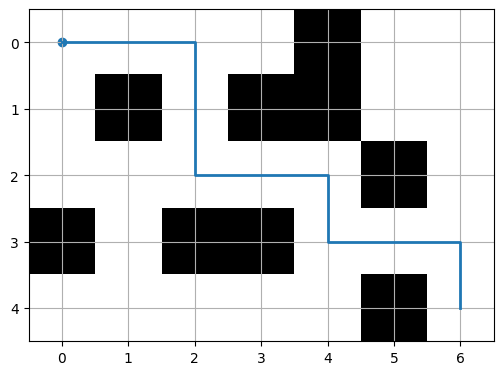

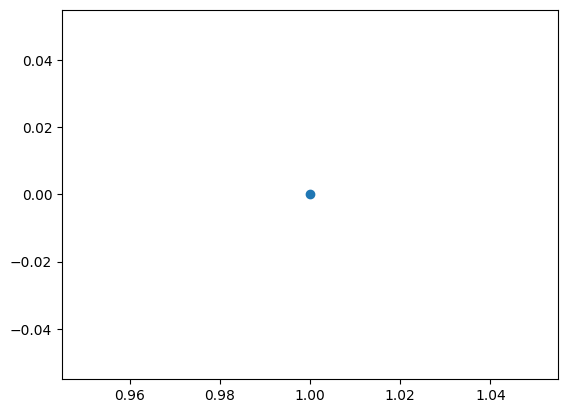

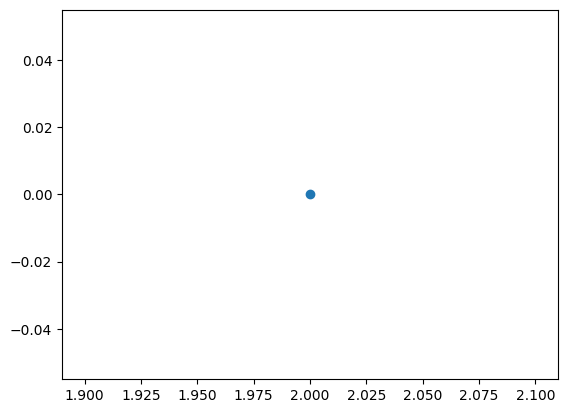

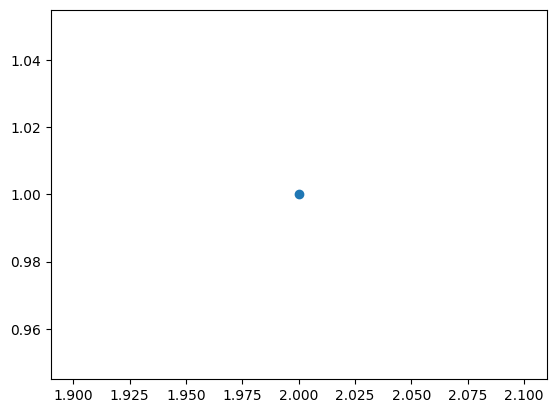

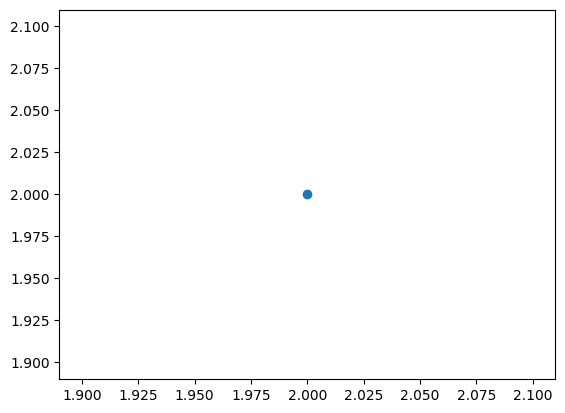

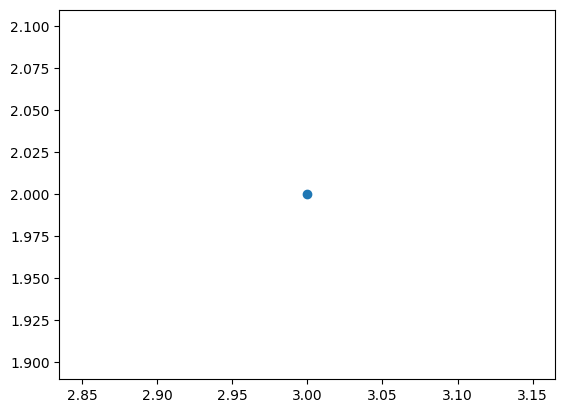

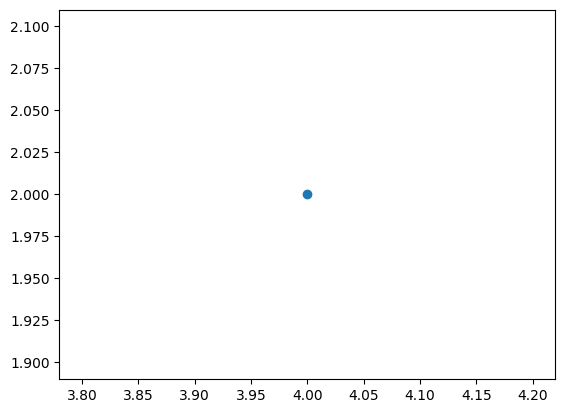

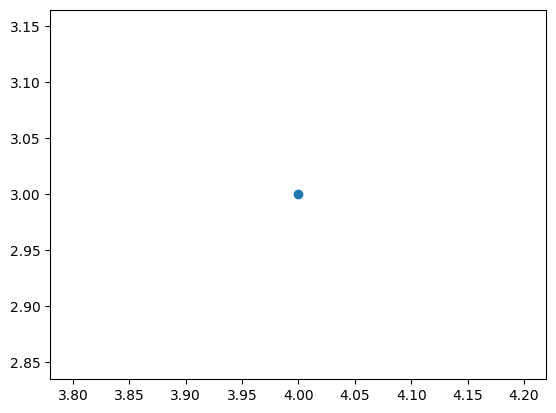

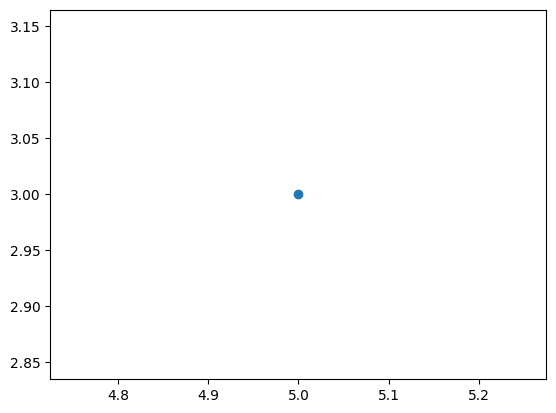

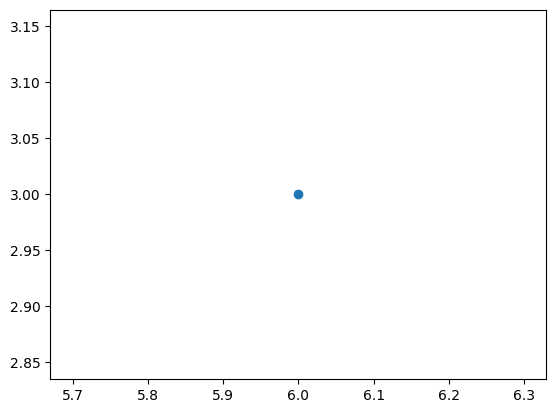

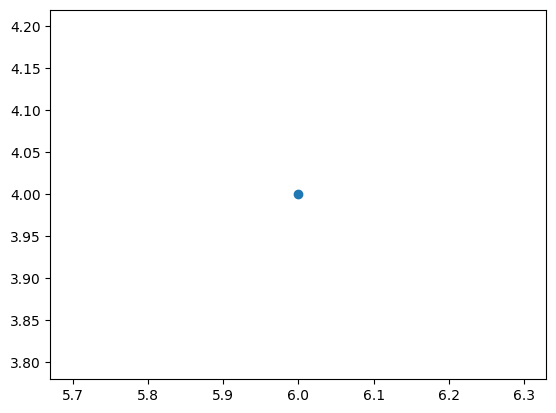

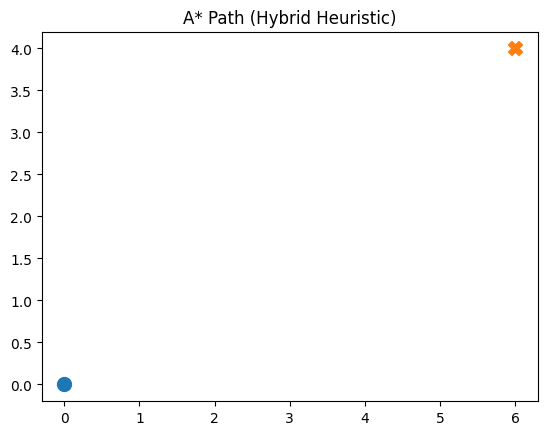

Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (3, 5), (3, 6), (4, 6)]
Path length: 11


In [ ]:
import heapq
import numpy as np
import math
import matplotlib.pyplot as plt

# -----------------------------
# GRID (0 = free, 1 = obstacle)
# -----------------------------
grid = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0]
])

start = (0, 0)
goal = (4, 6)

# -----------------------------
# HYBRID HEURISTIC
# -----------------------------
def hybrid_distance(a, b, alpha=0.3, beta=0.7):
    dx = abs(a[0] - b[0])
    dy = abs(a[1] - b[1])

    manhattan = dx + dy
    euclidean = math.sqrt(dx*dx + dy*dy)

    return alpha * manhattan + beta * euclidean


# -----------------------------
# GET NEIGHBORS (8 directions)
# -----------------------------
def get_neighbors(node):
    x, y = node

    directions = [
        (1, 0), (-1, 0), (0, 1), (0, -1),   # straight
        (1, 1), (1, -1), (-1, 1), (-1, -1)  # diagonal
    ]

    neighbors = []

    for dx, dy in directions:
        nx, ny = x + dx, y + dy

        if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
            if grid[nx][ny] == 0:

                # Prevent corner cutting
                if abs(dx) == 1 and abs(dy) == 1:
                    if grid[x+dx][y] == 1 or grid[x][y+dy] == 1:
                        continue

                cost = 1.414 if dx != 0 and dy != 0 else 1
                neighbors.append(((nx, ny), cost))

    return neighbors


# -----------------------------
# A* ALGORITHM
# -----------------------------
def astar(start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    g_cost = {start: 0}

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            break

        for neighbor, move_cost in get_neighbors(current):
            new_g = g_cost[current] + move_cost

            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g

                h = hybrid_distance(neighbor, goal)
                f = new_g + h

                heapq.heappush(open_list, (f, neighbor))
                came_from[neighbor] = current

    # reconstruct path
    path = []
    node = goal
    while node in came_from:
        path.append(node)
        node = came_from[node]
    path.append(start)
    path.reverse()

    return path


# -----------------------------
# RUN
# -----------------------------
path = astar(start, goal)
print("Path:", path)

def visualize(grid, path, start, goal):
    plt.figure(figsize=(6,6))

    # Show grid (clear contrast)
    plt.imshow(grid, cmap='Greys')

    # Draw grid lines
    plt.xticks(range(grid.shape[1]))
    plt.yticks(range(grid.shape[0]))
    plt.grid(True)

    # Plot full path line
    y_coords = [y for x, y in path]
    x_coords = [x for x, y in path]

    plt.plot(y_coords, x_coords, linewidth=2)

    # Animate movement
    for (x, y) in path:
        plt.scatter(y, x)
        plt.pause(0.2)

    # Mark start & goal
    plt.scatter(start[1], start[0], s=100, marker='o')
    plt.scatter(goal[1], goal[0], s=100, marker='X')

    plt.title("A* Path (Hybrid Heuristic)")
    plt.show()


visualize(grid, path, start, goal)
print("Path:", path)
print("Path length:", len(path))

**THE BELOW ONE IS 1ST OPTIMIZED CODE . IN WHICH THE CODE TRIES TO MOVE AS MUCH DIAGONALLY AS IT CAN . AND WHEN THERE IS RESTRICTION , IT MOVES IN ZIG ZAG .
IN THIS CODE, WE ARE MOVING IN A GRID , SO IT HAS TO MOVE FROM POINT TO POINT, IT CAN'T MOVE IN THE SPACE BETWEEN THE POINTS (GRID POINTS)
ANIMATION IS ALSO ADDED IN THIS CODE . FOR THIS ANIMATIN, IT CREATES MULTIPLE IMAGES LIKE FRAMES PER SECOND.**

✅ Using Straight Line Path
Path: [(0, 0), (1, 1), (2, 2), (3, 2), (4, 3), (5, 4)]


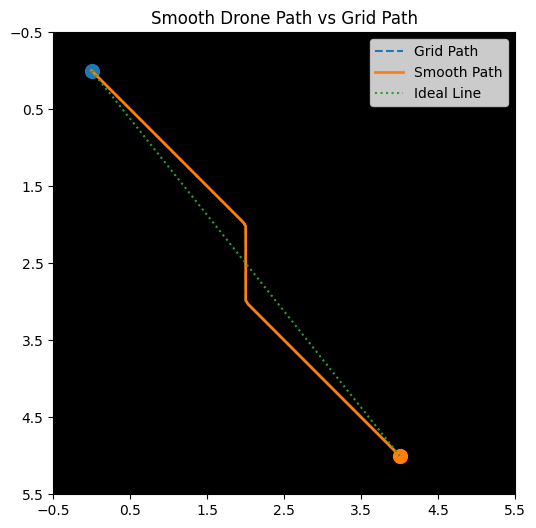

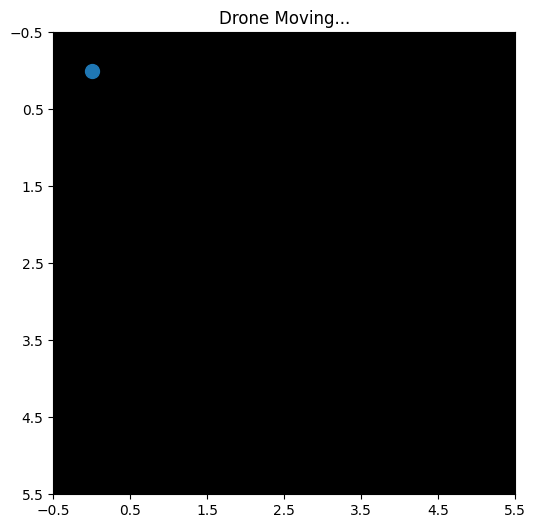

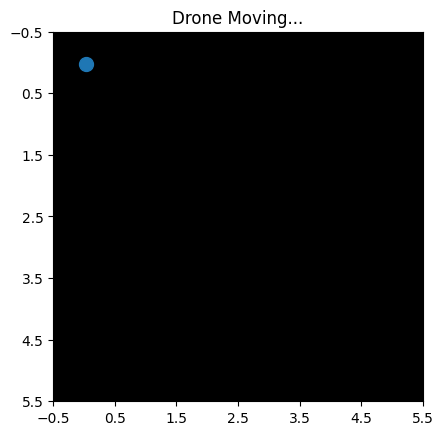

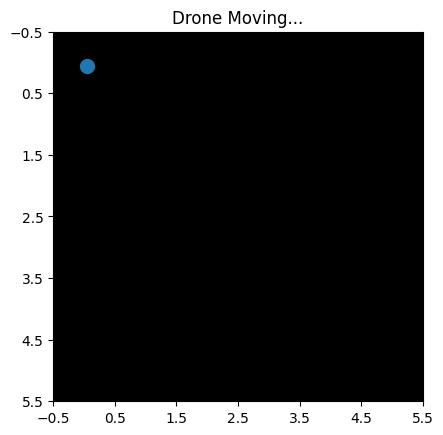

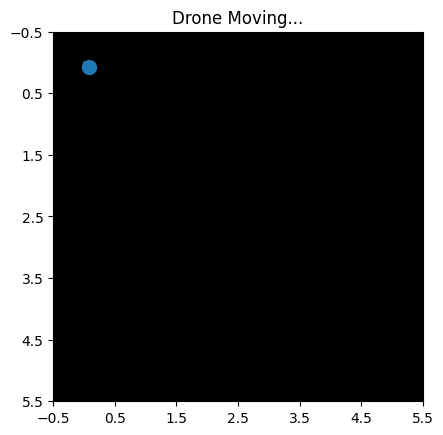

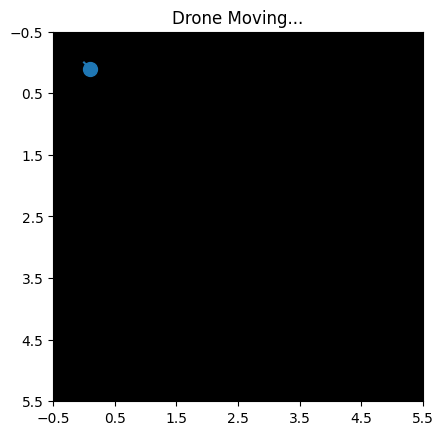

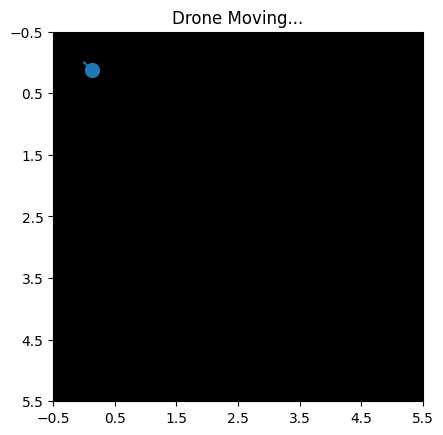

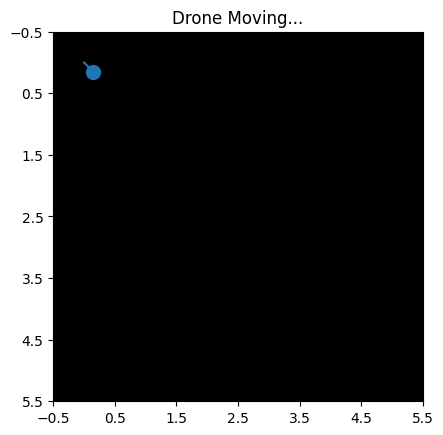

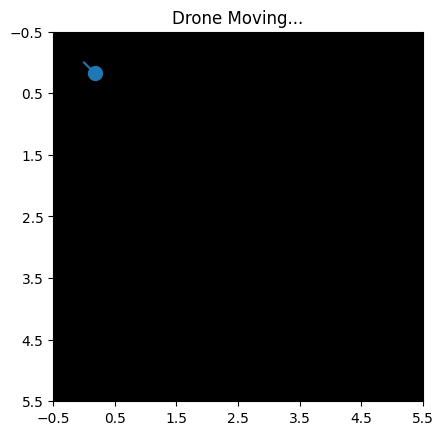

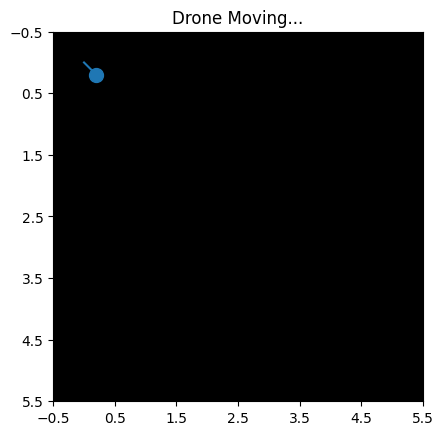

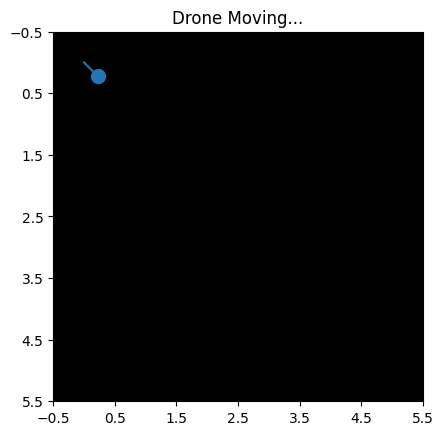

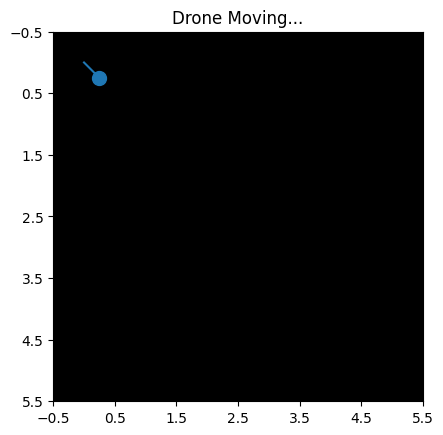

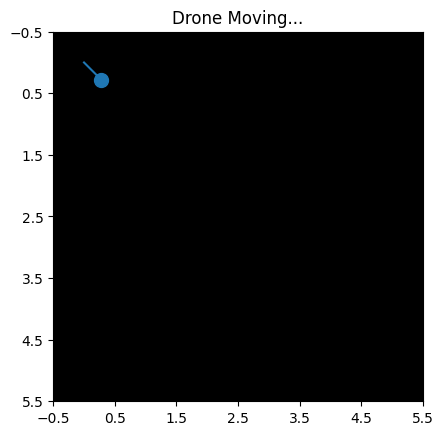

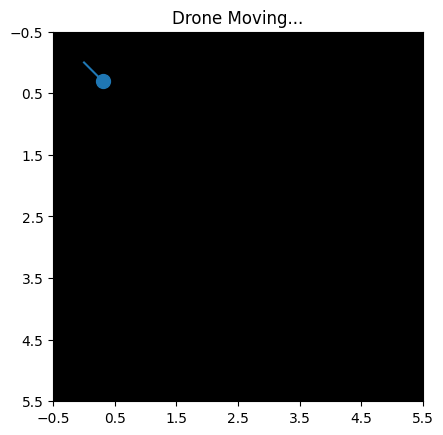

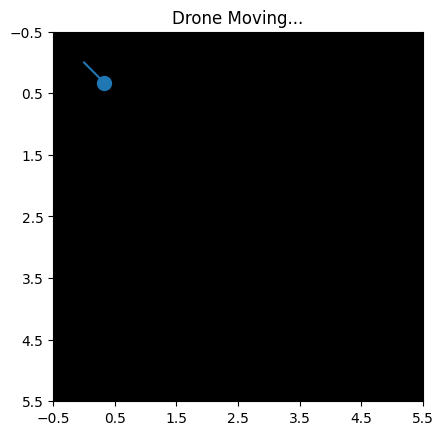

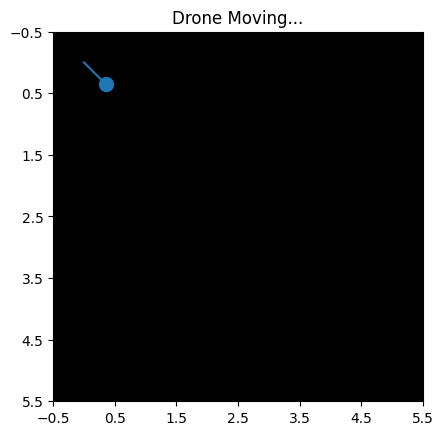

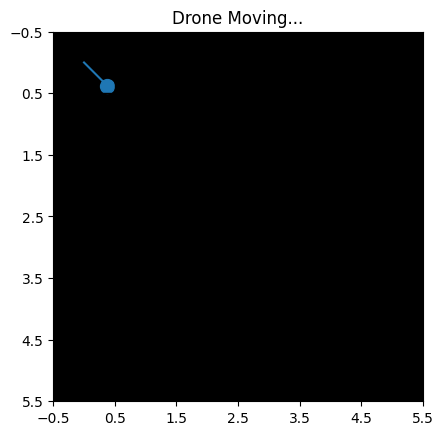

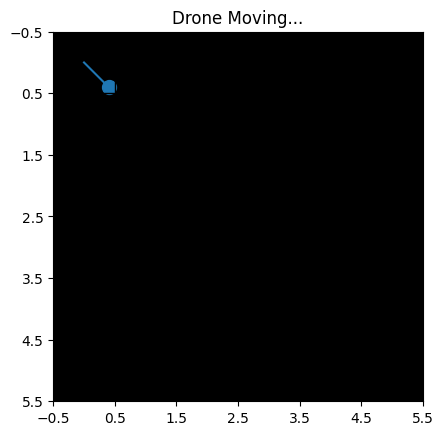

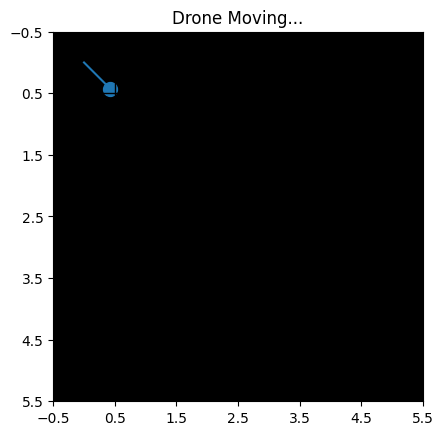

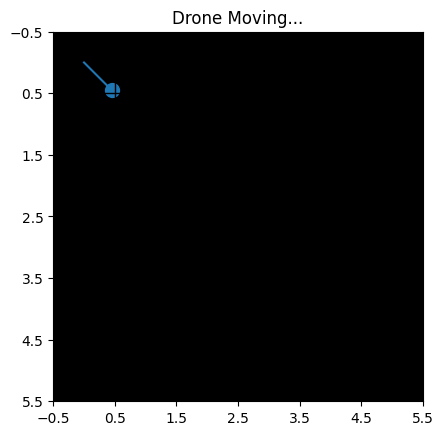

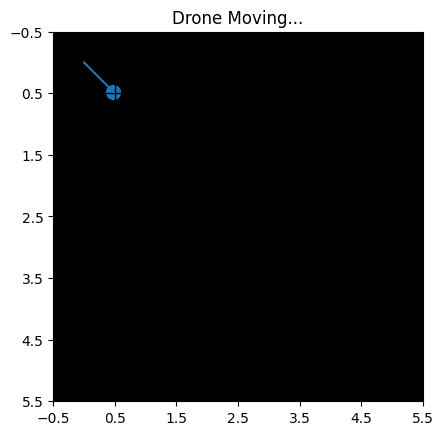

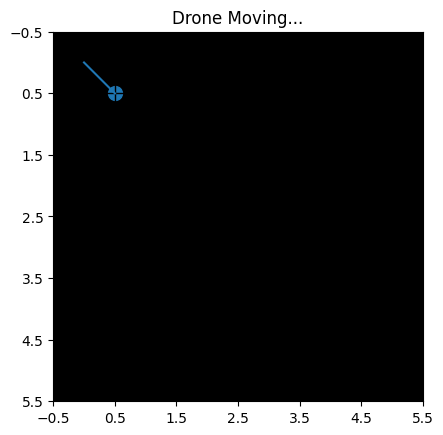

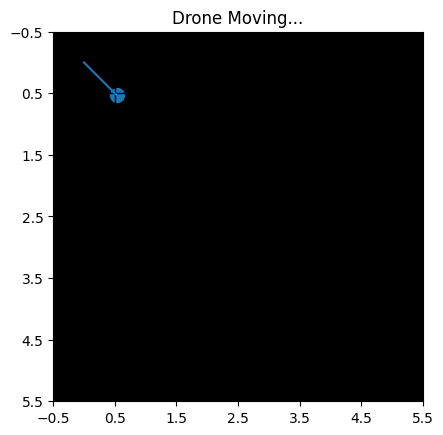

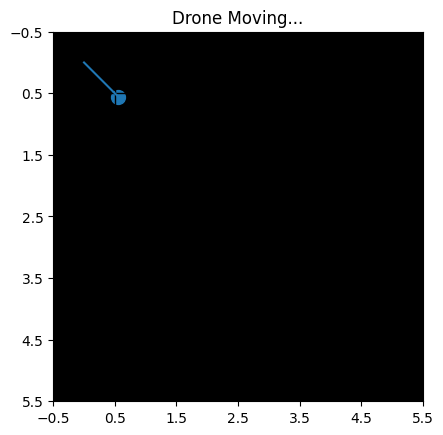

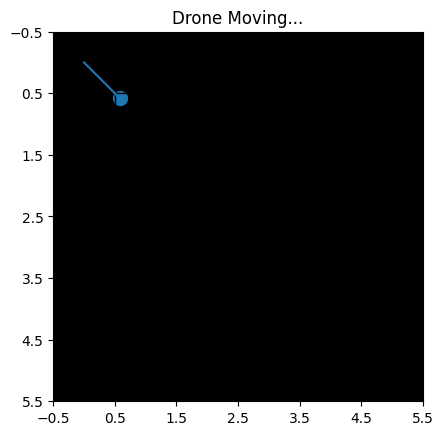

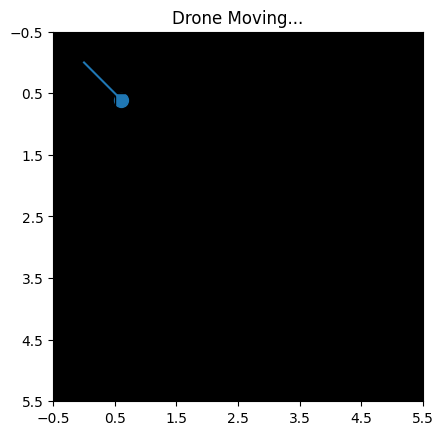

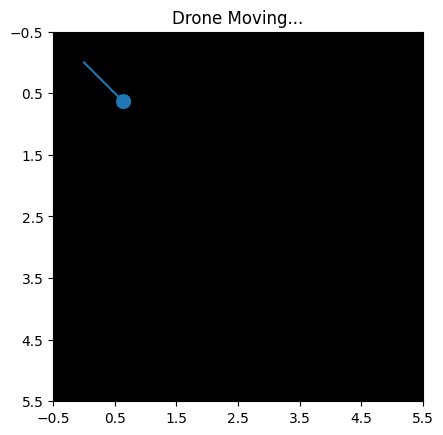

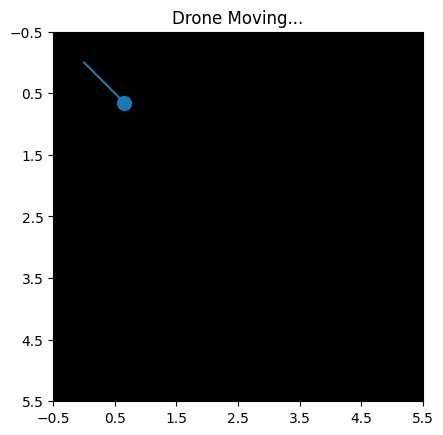

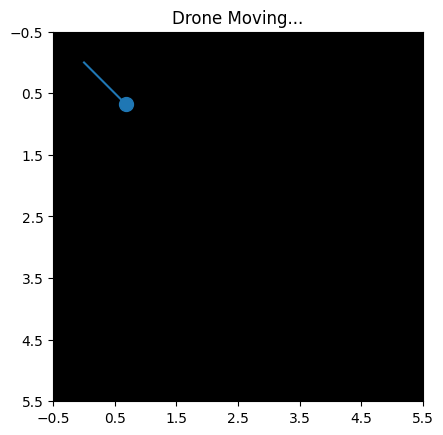

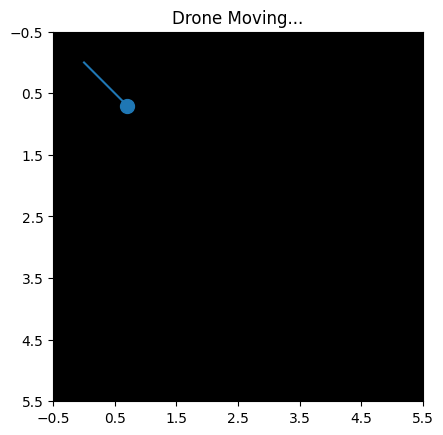

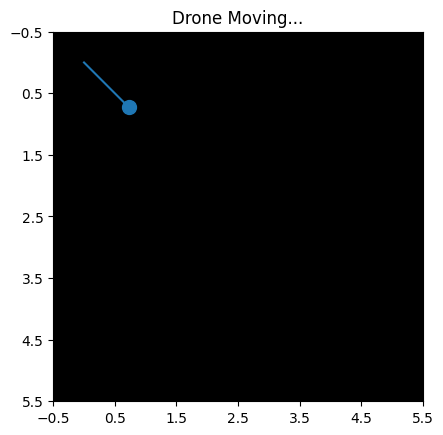

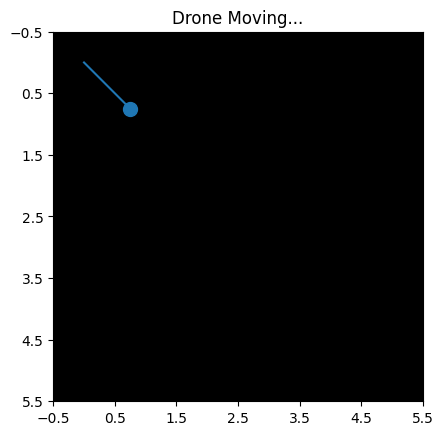

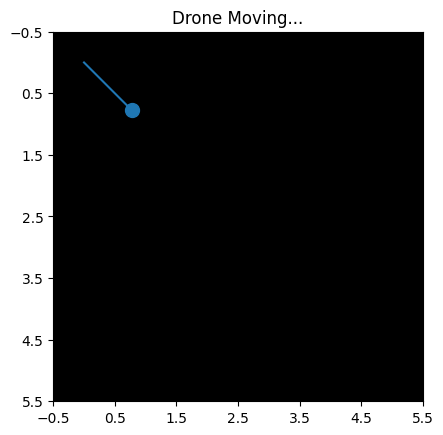

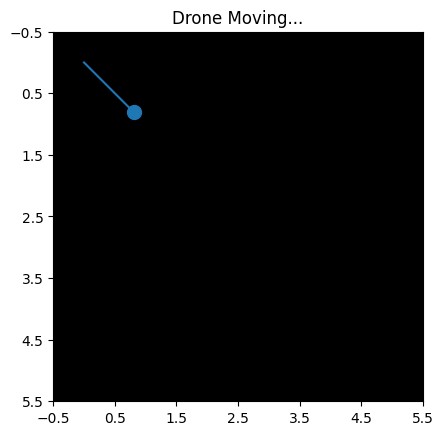

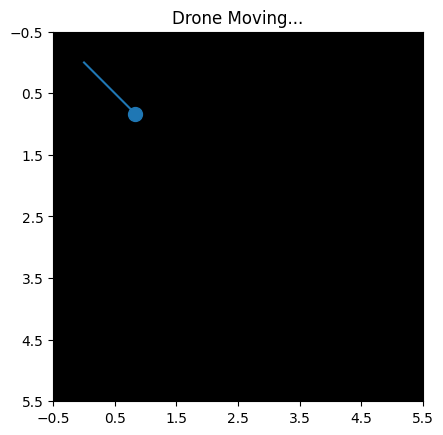

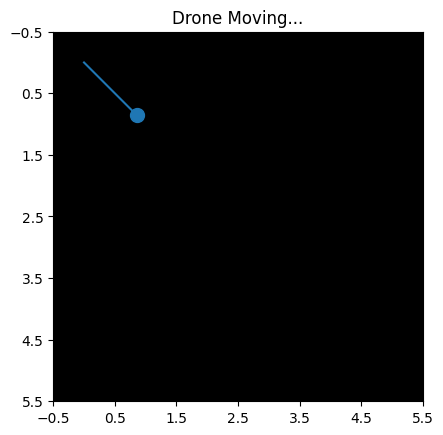

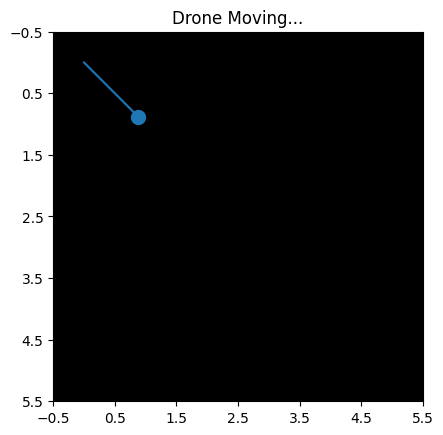

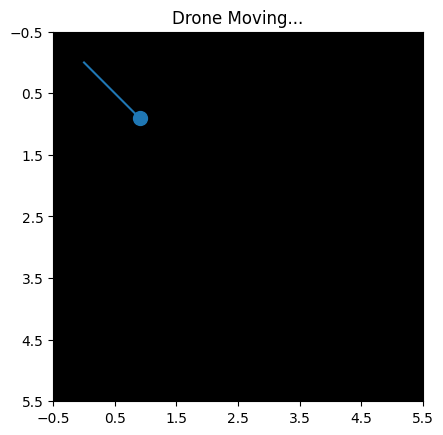

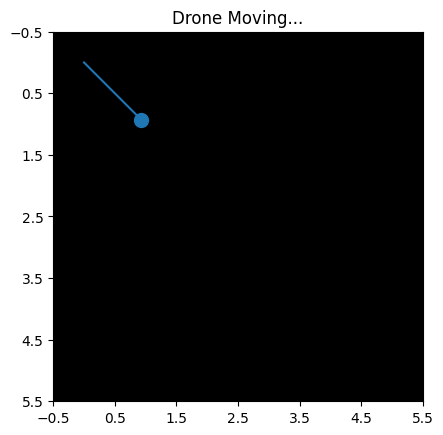

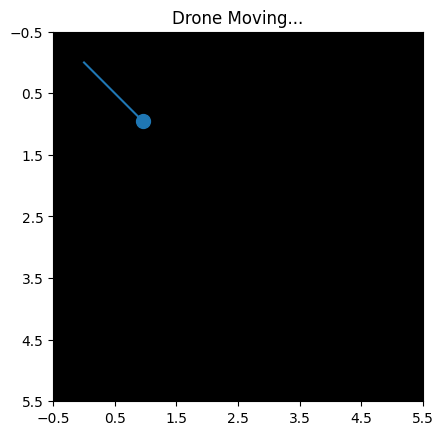

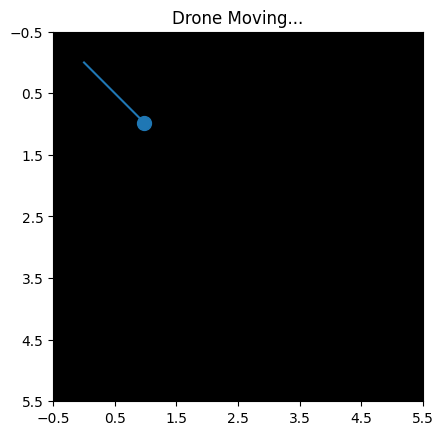

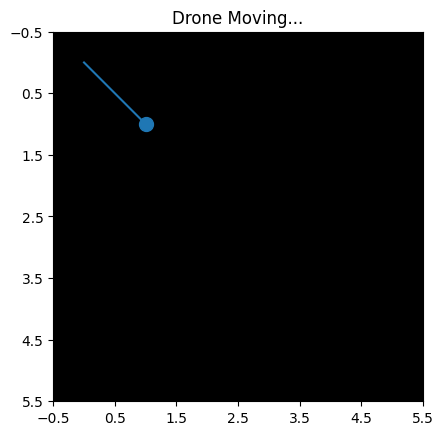

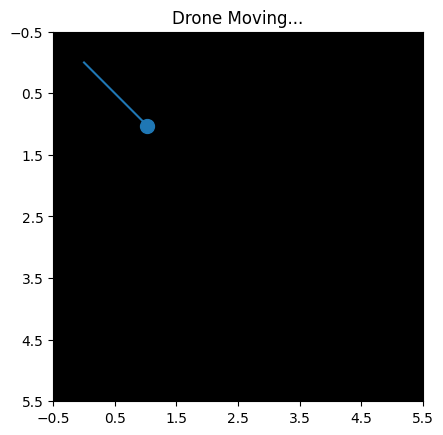

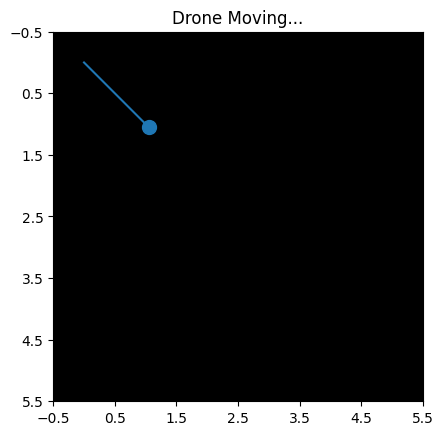

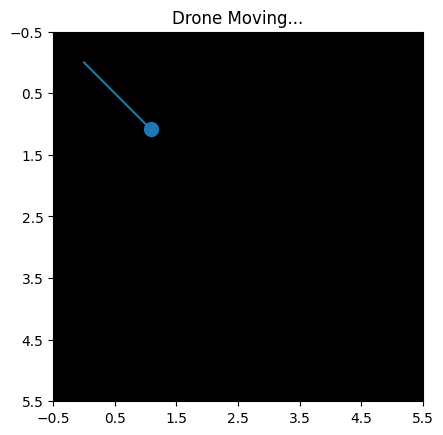

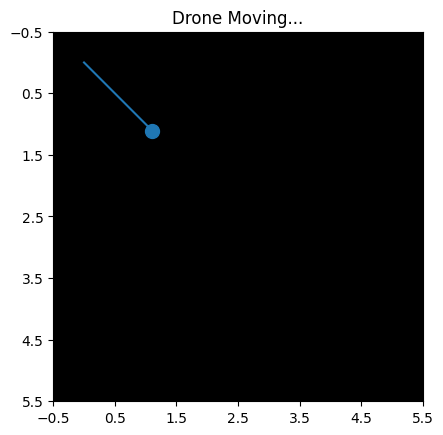

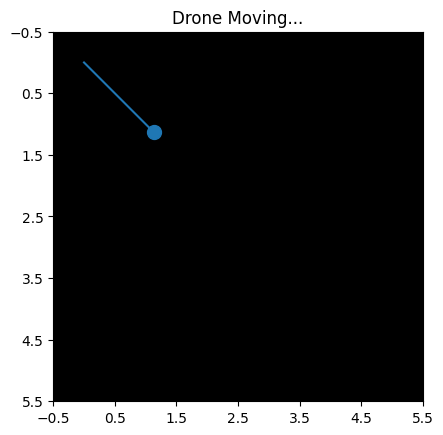

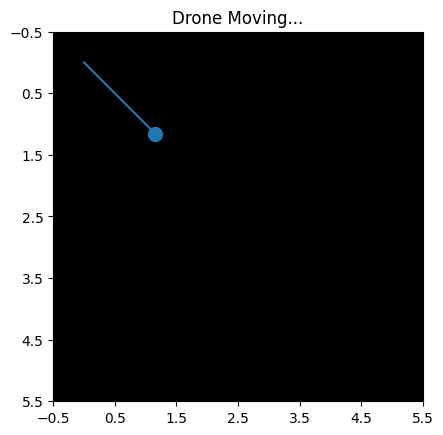

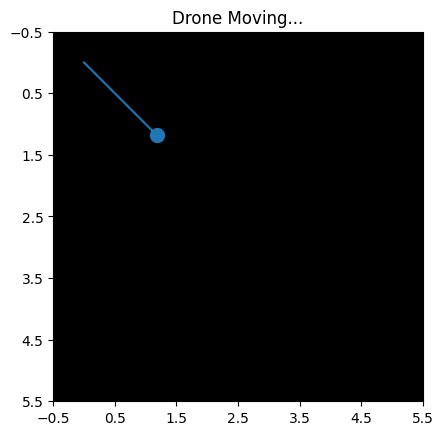

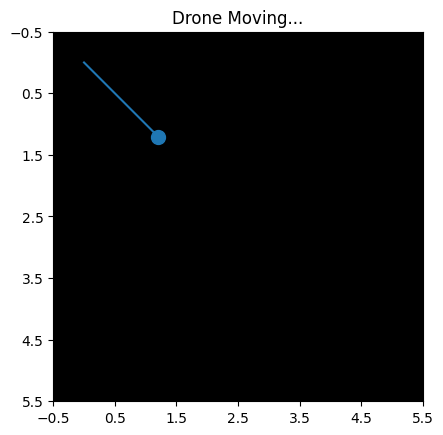

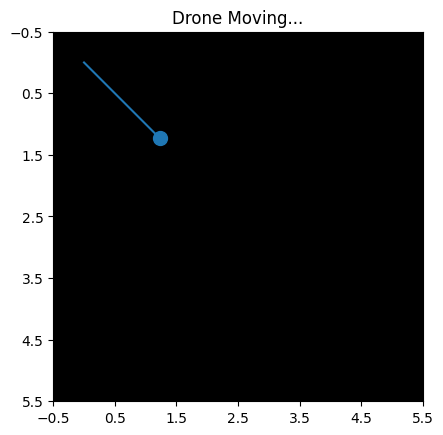

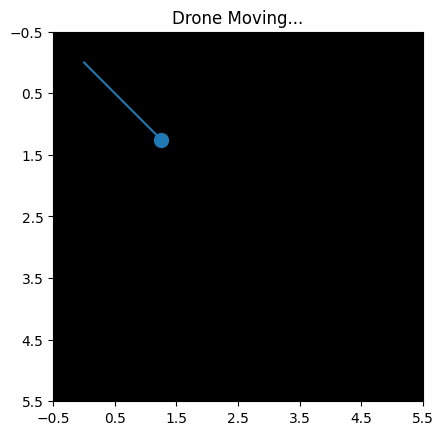

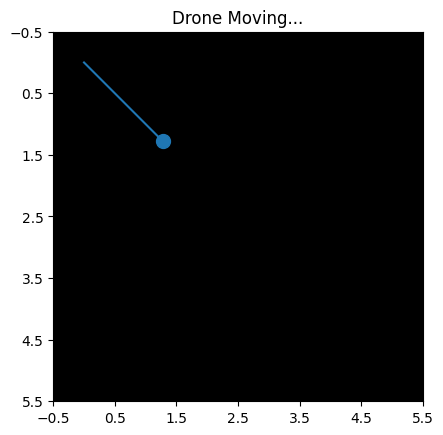

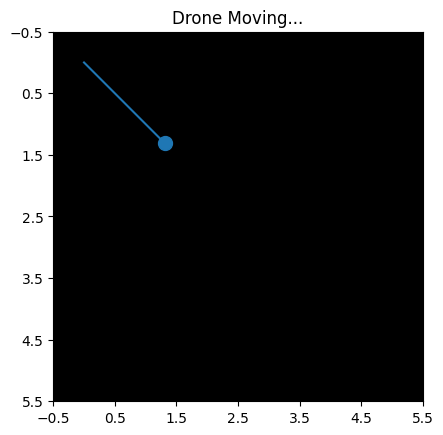

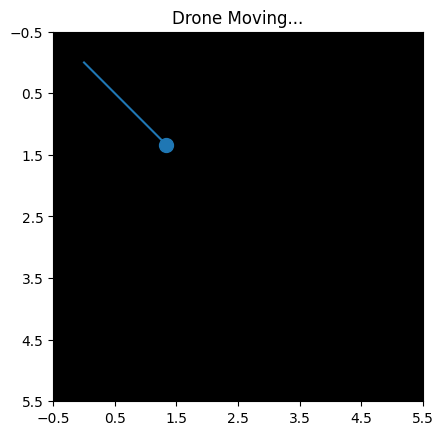

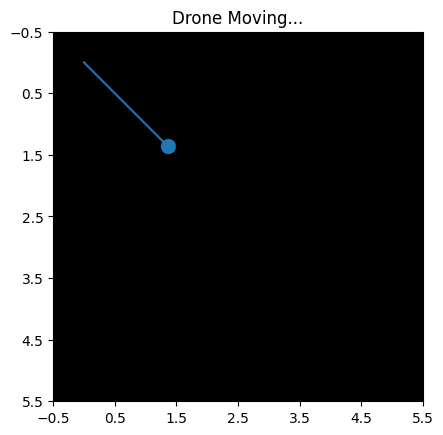

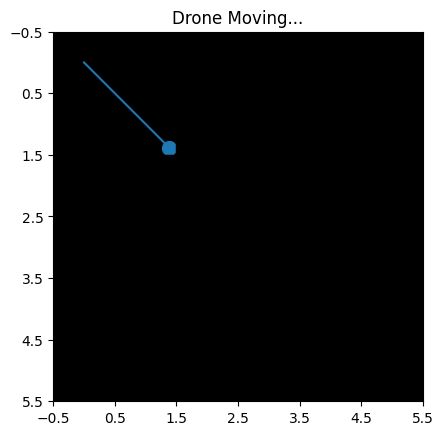

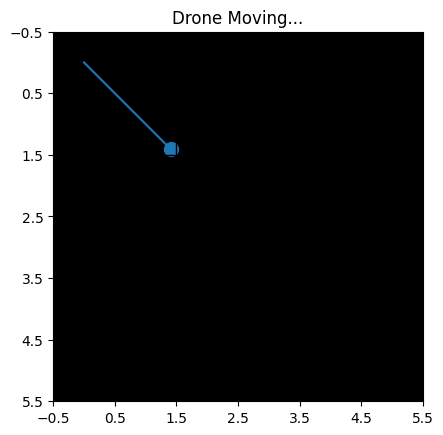

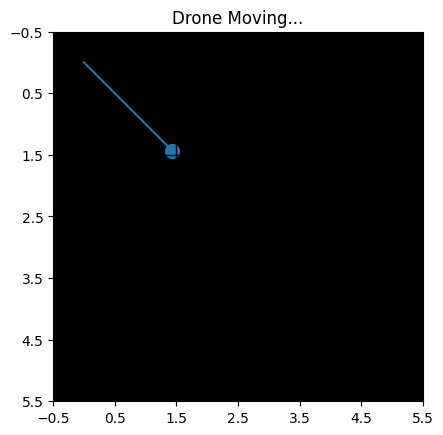

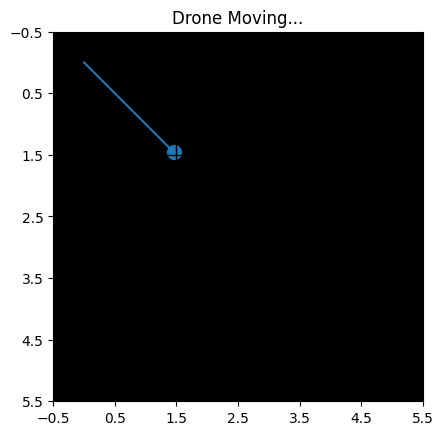

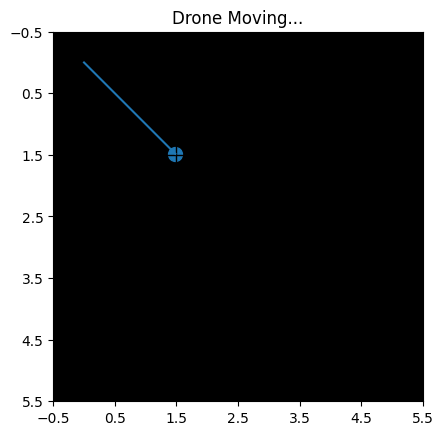

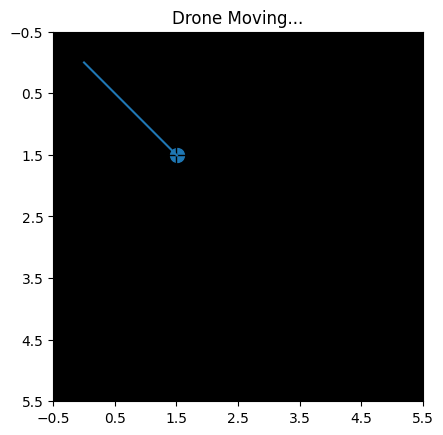

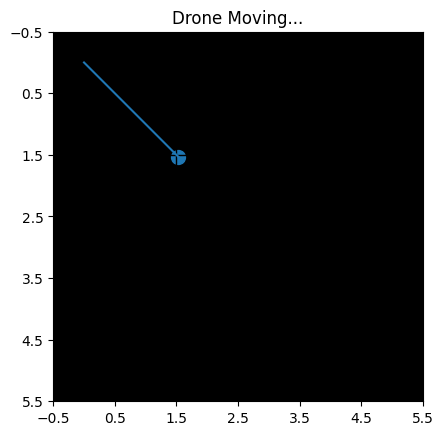

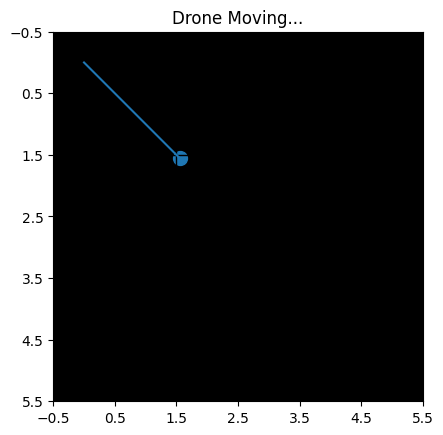

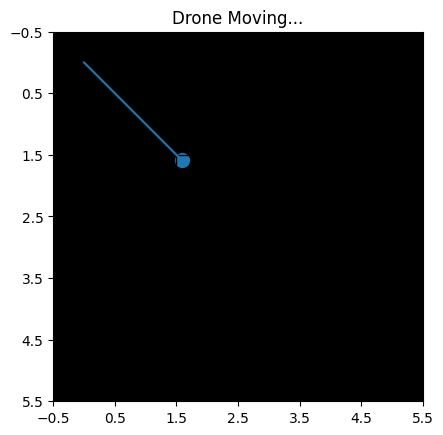

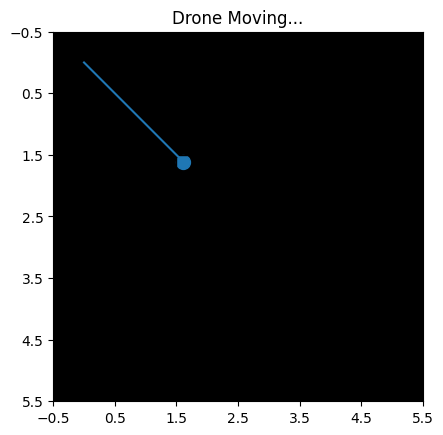

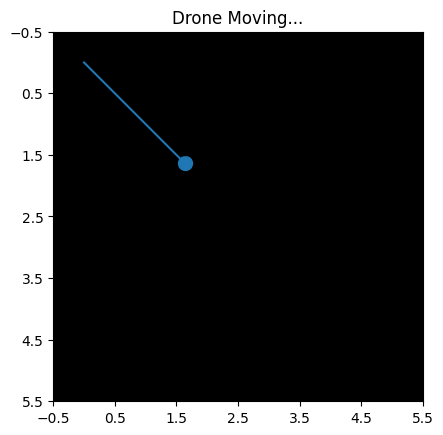

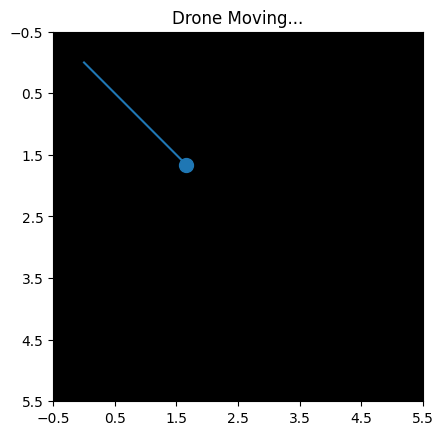

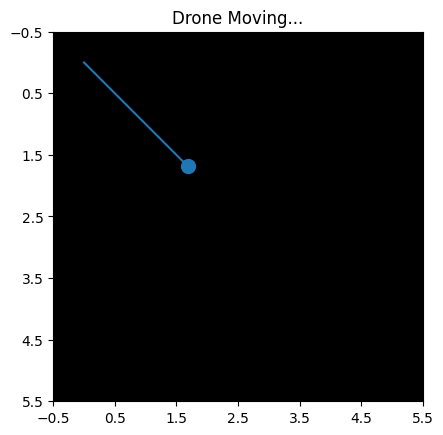

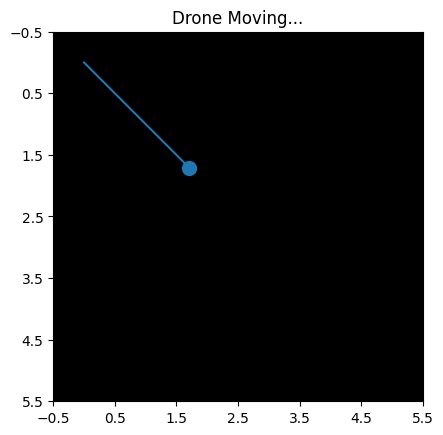

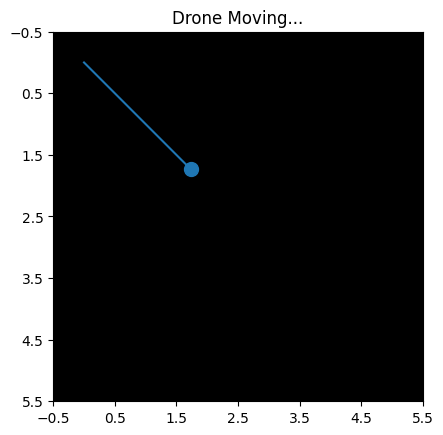

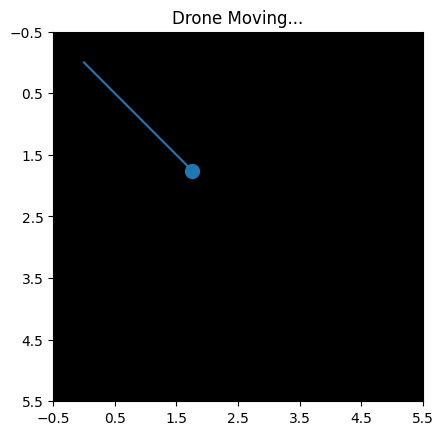

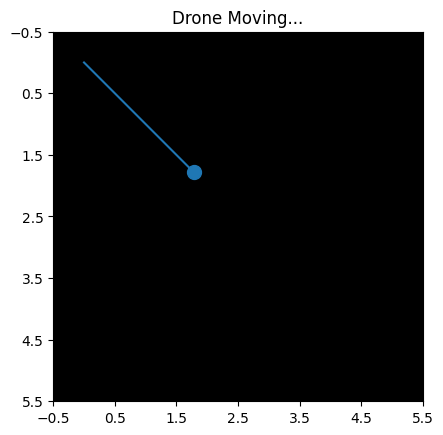

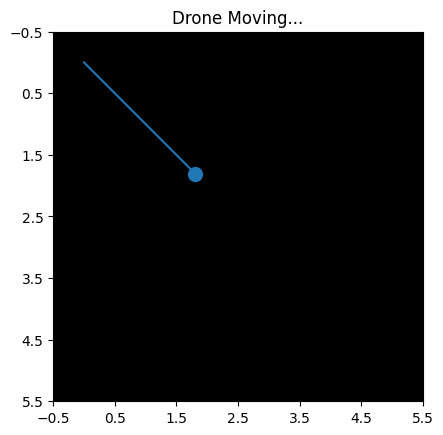

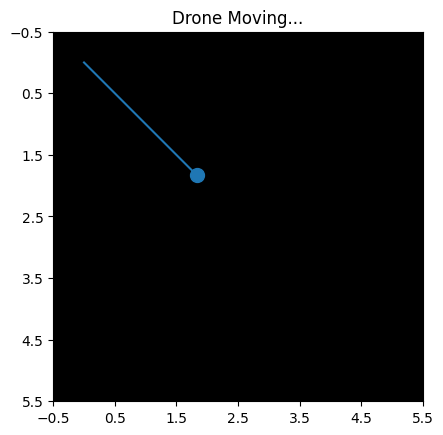

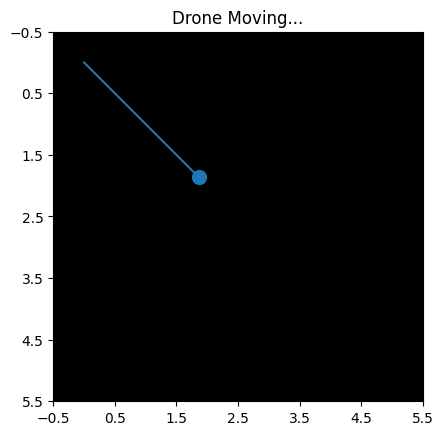

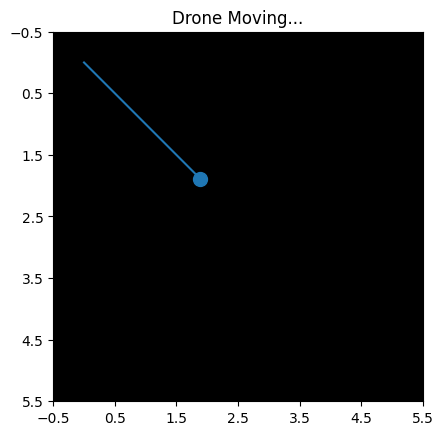

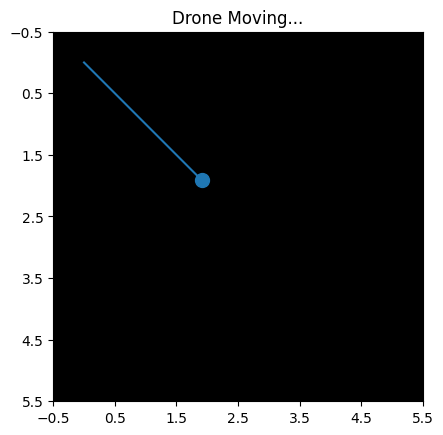

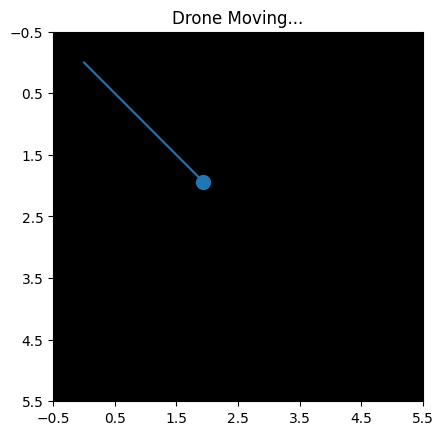

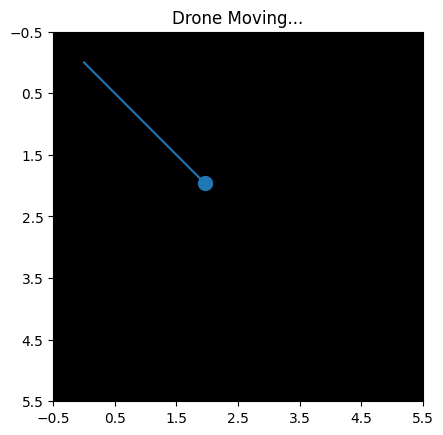

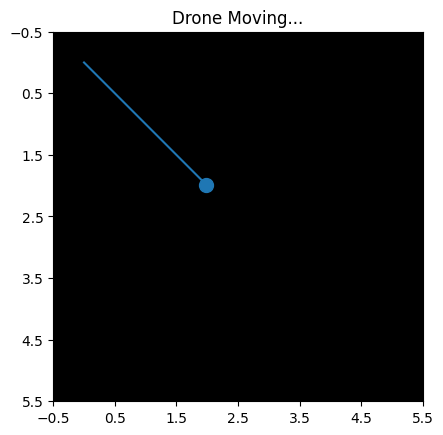

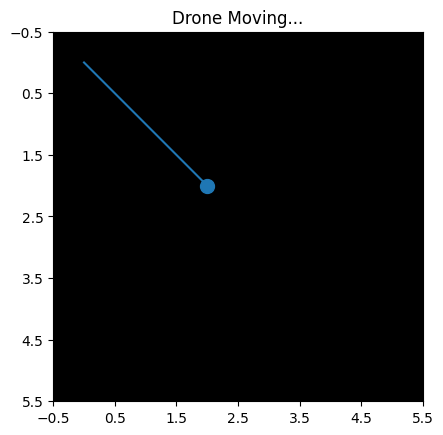

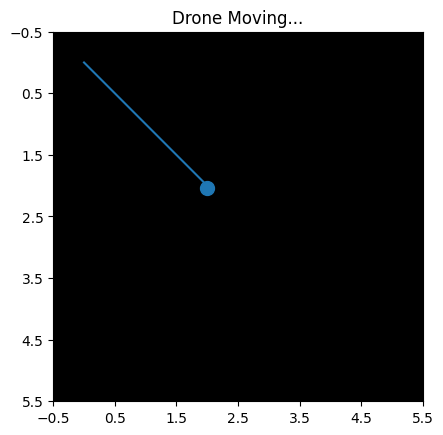

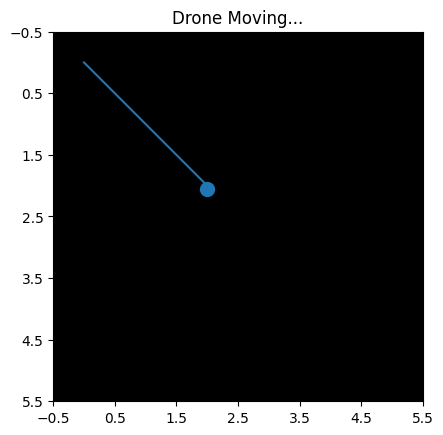

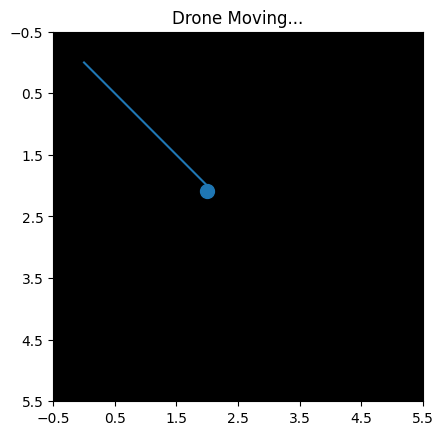

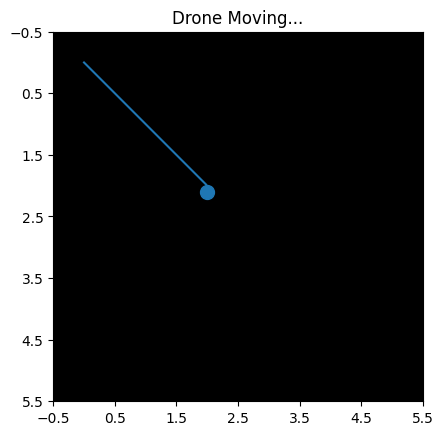

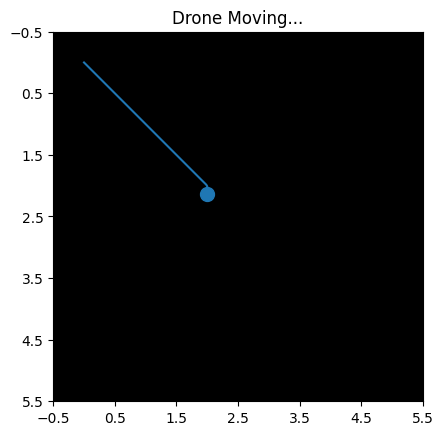

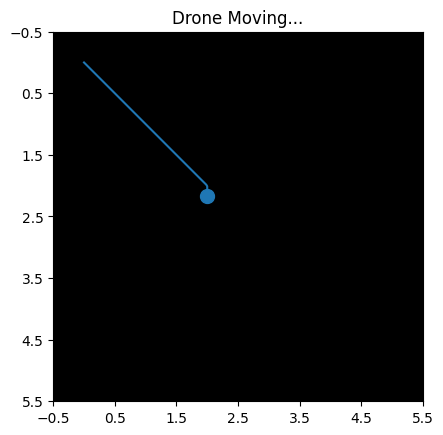

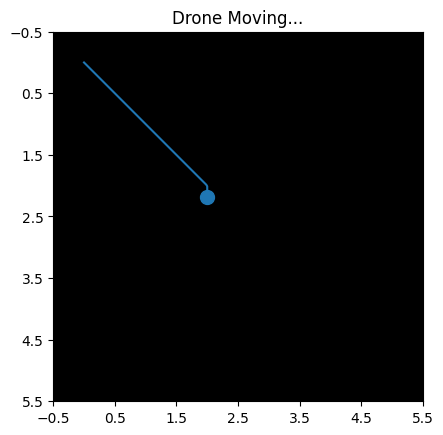

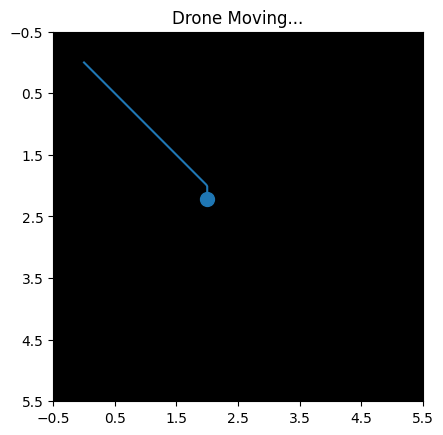

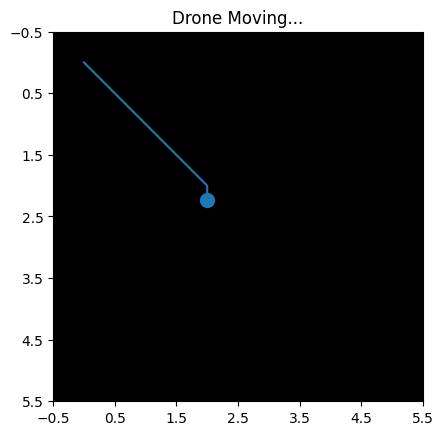

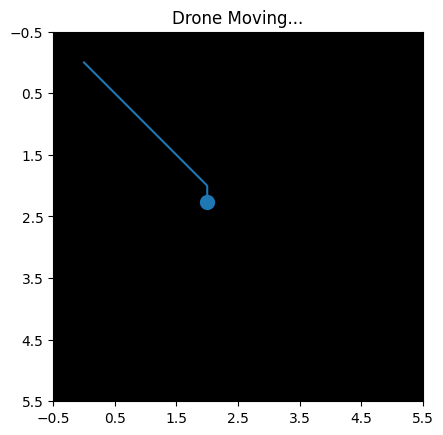

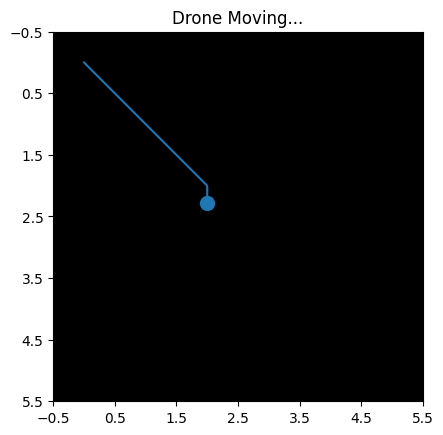

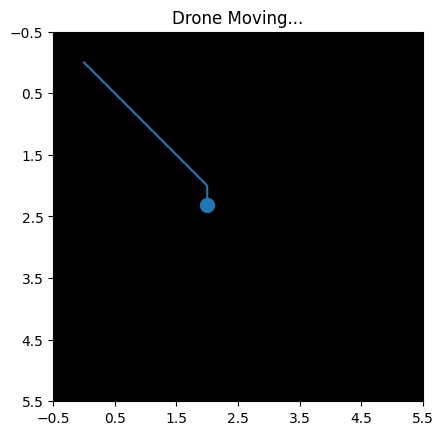

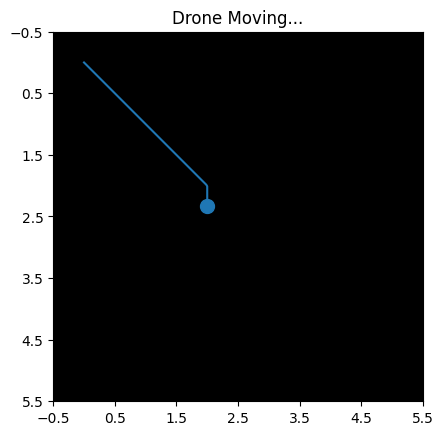

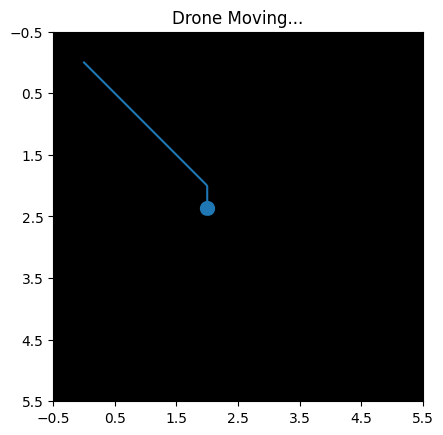

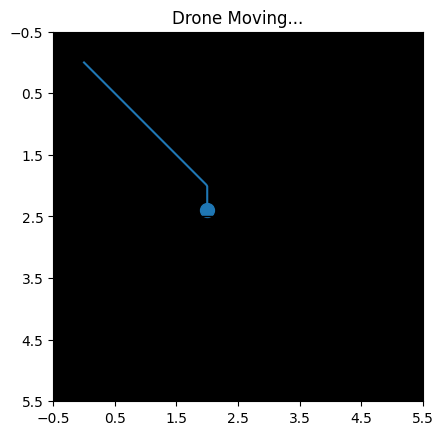

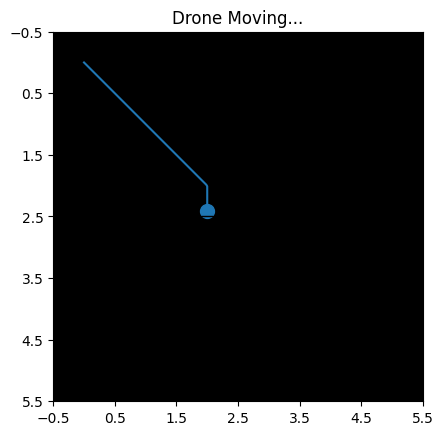

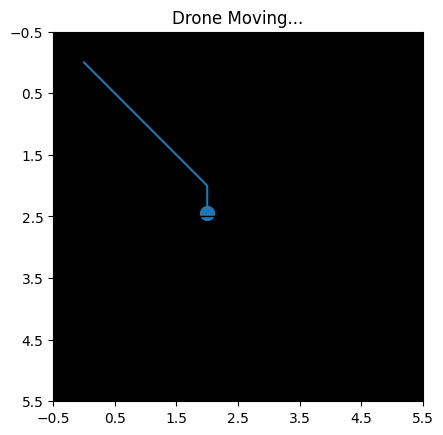

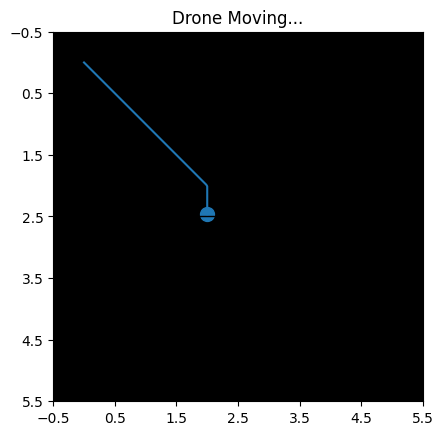

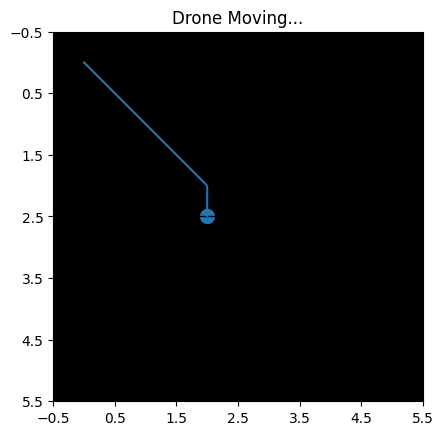

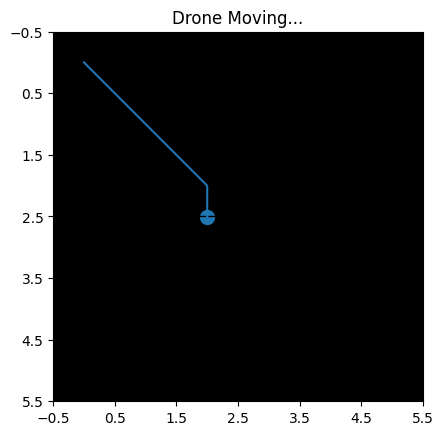

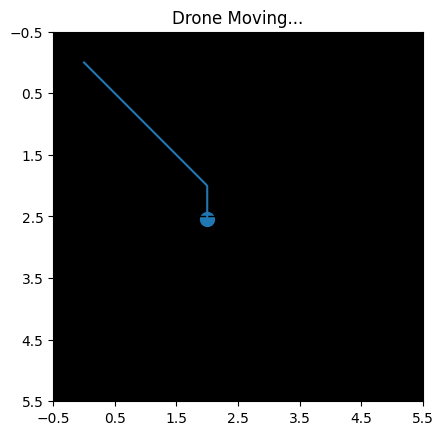

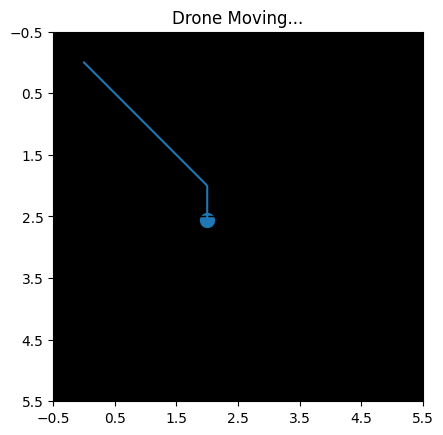

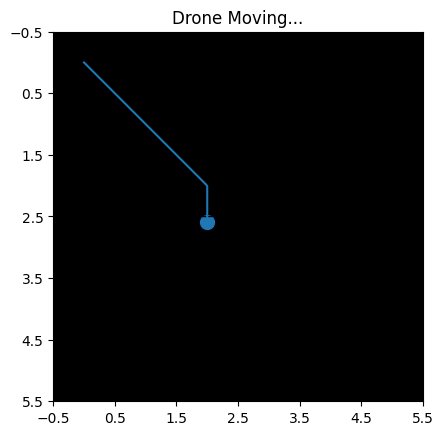

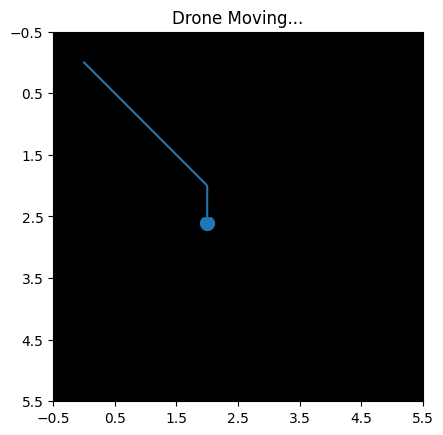

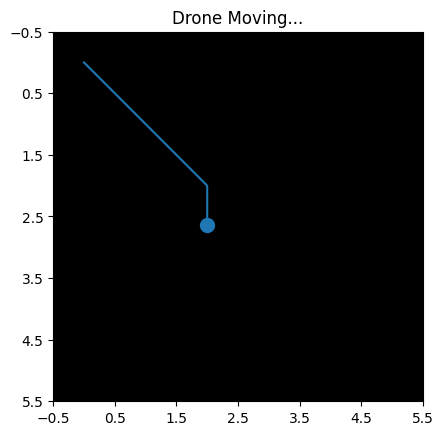

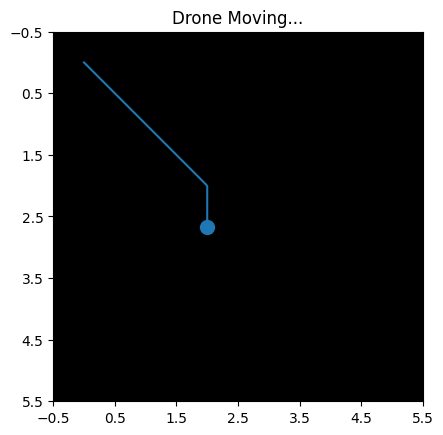

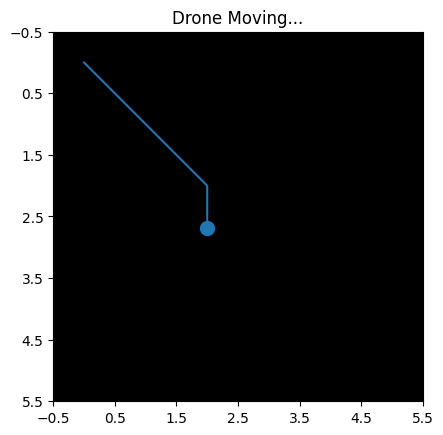

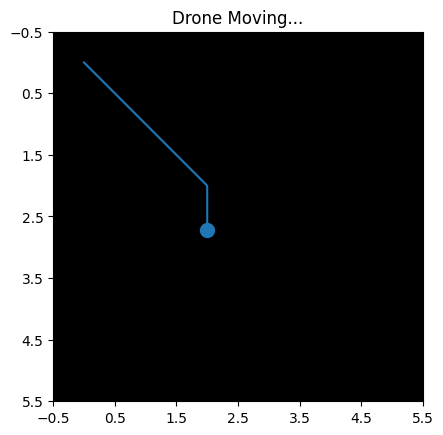

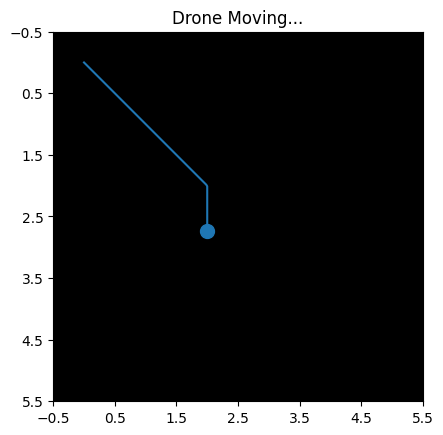

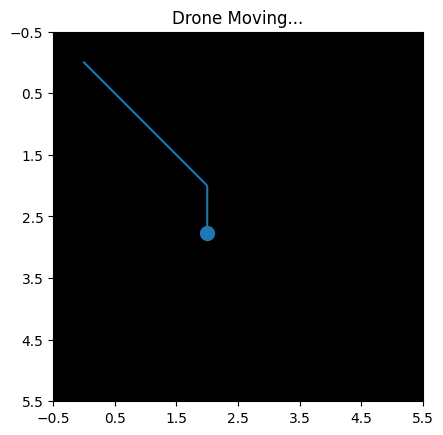

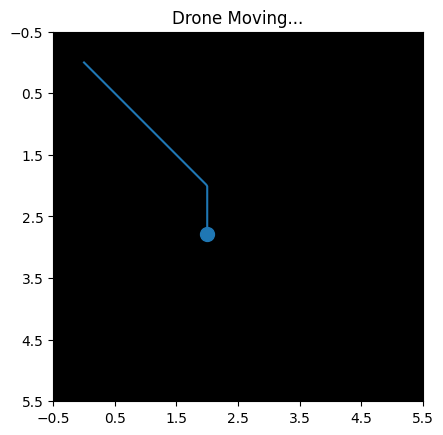

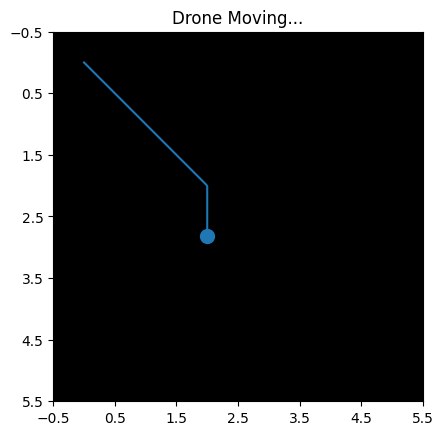

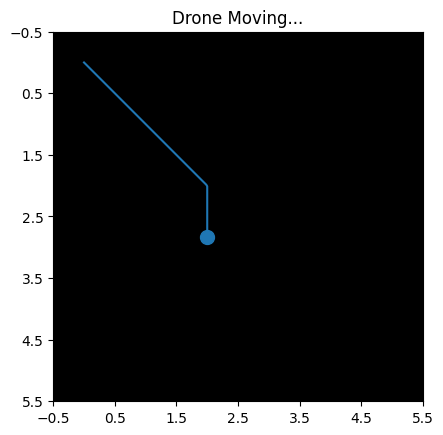

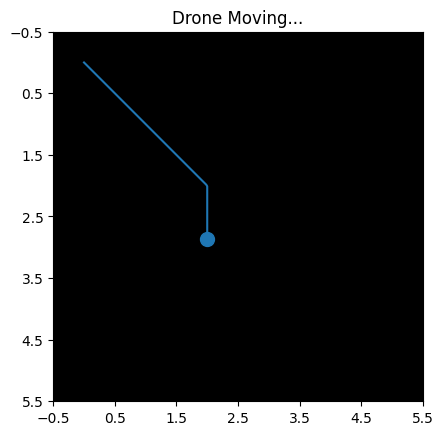

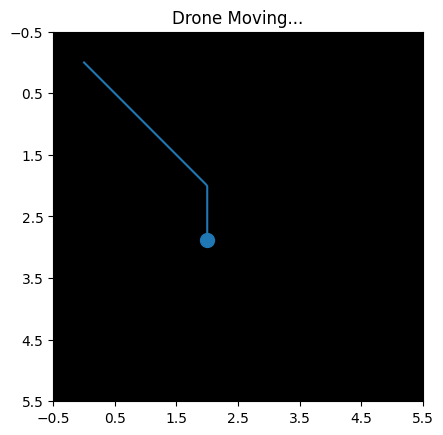

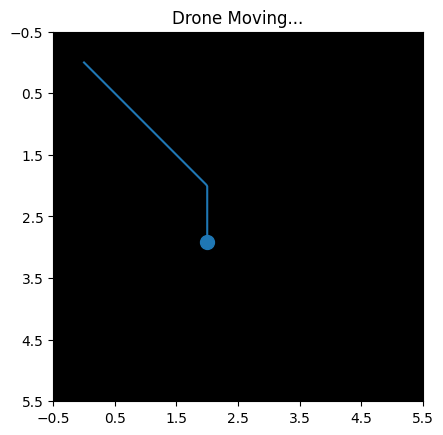

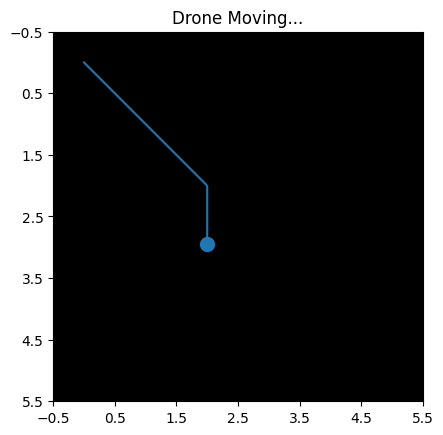

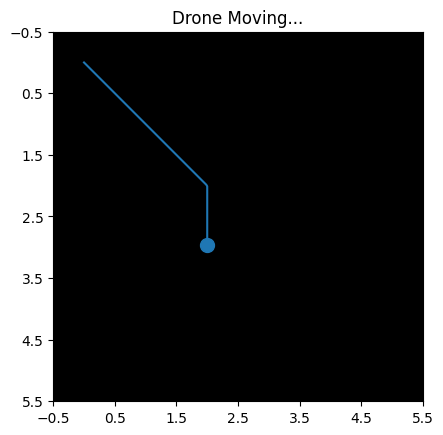

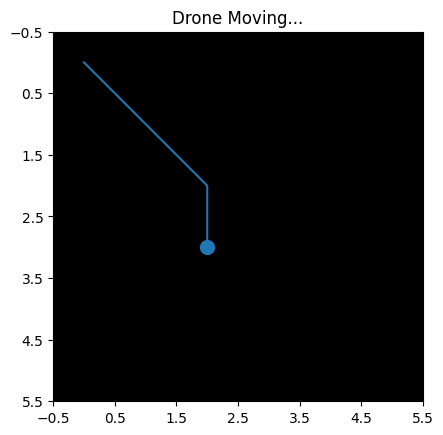

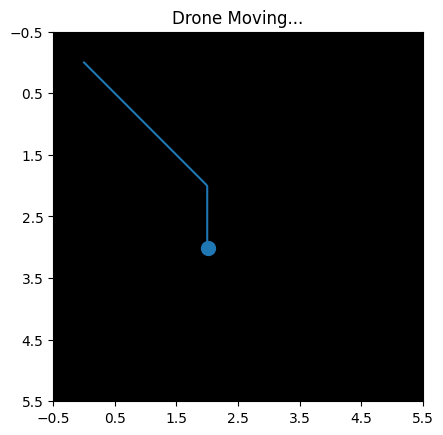

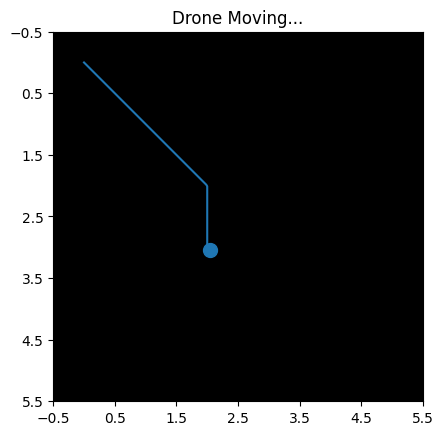

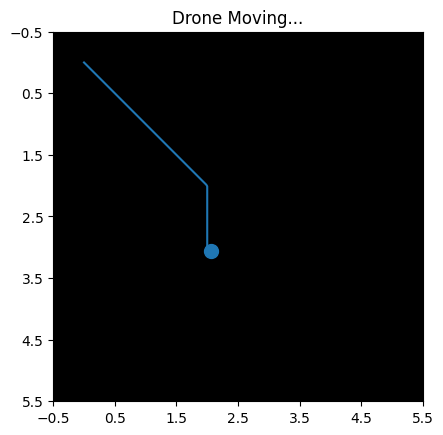

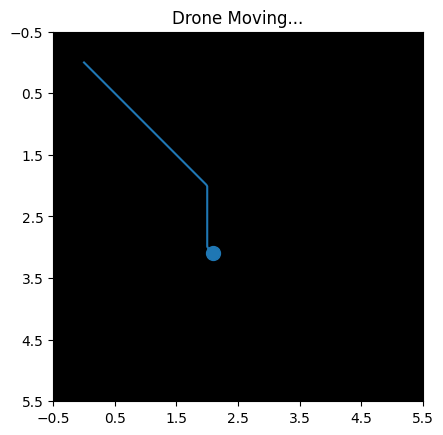

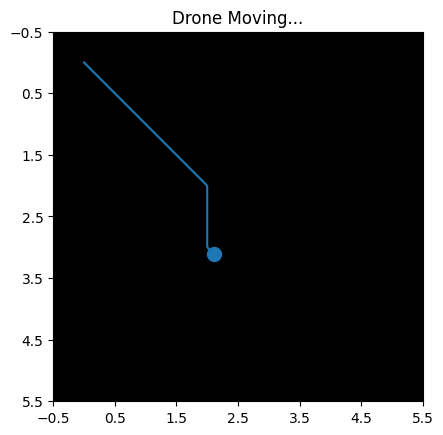

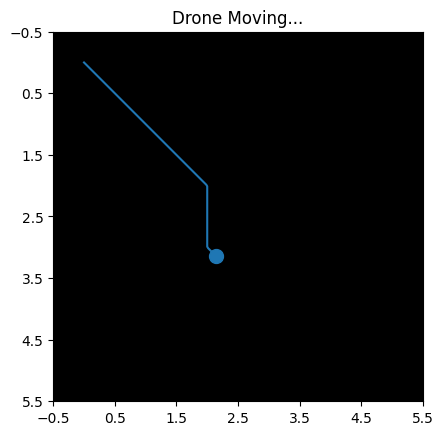

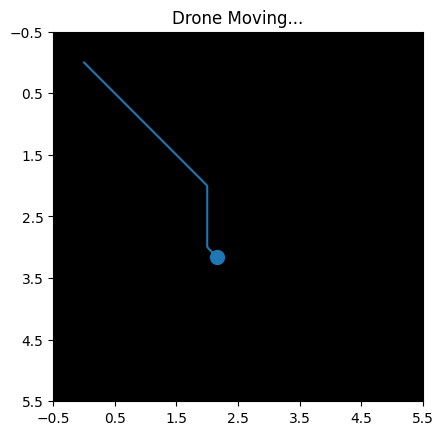

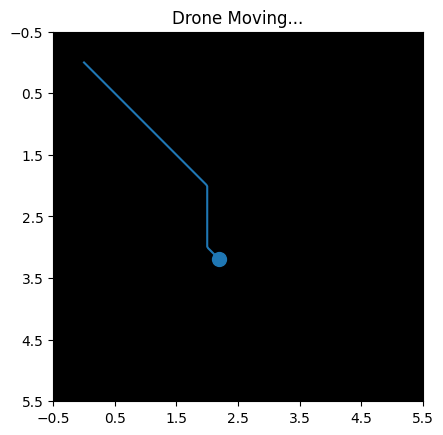

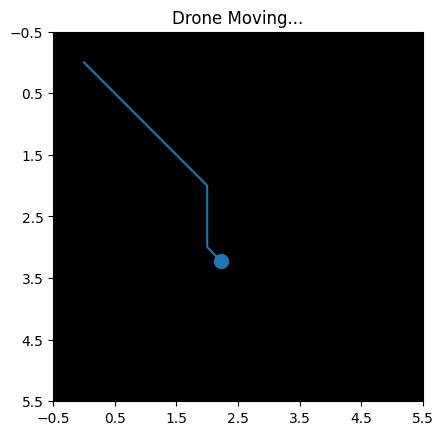

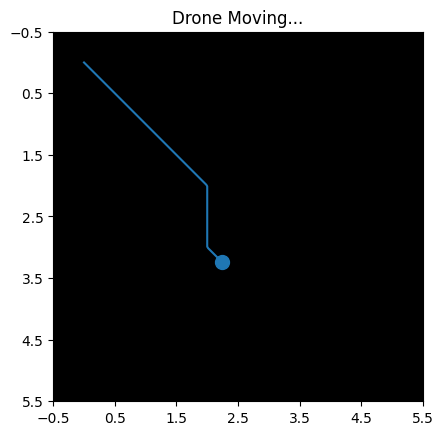

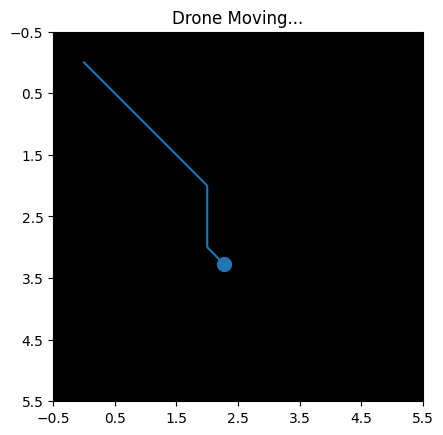

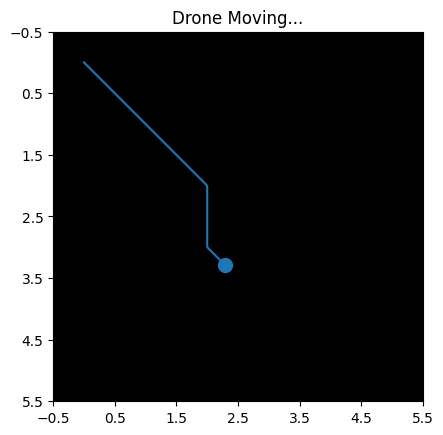

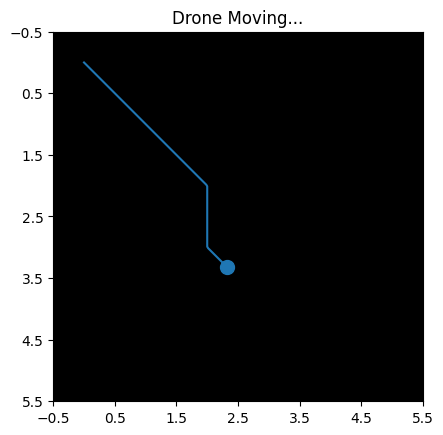

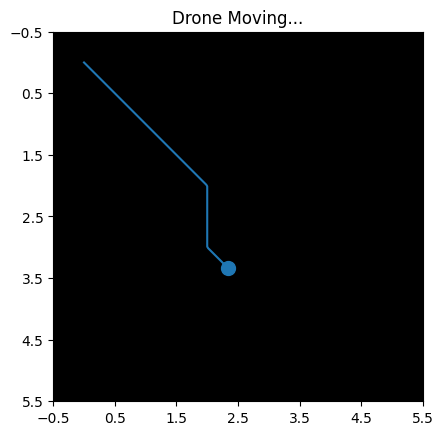

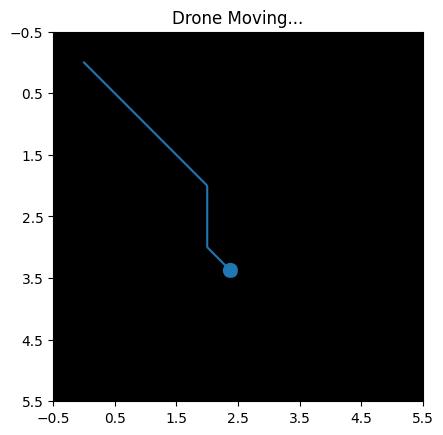

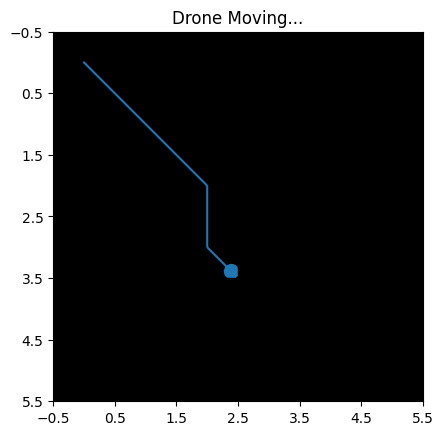

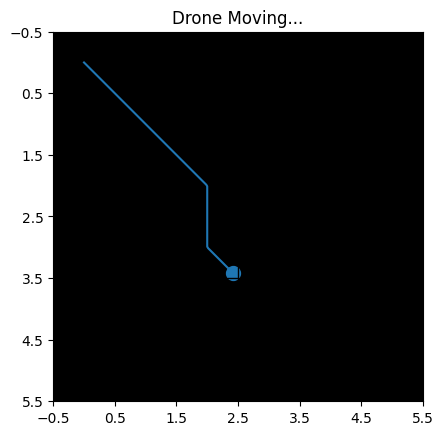

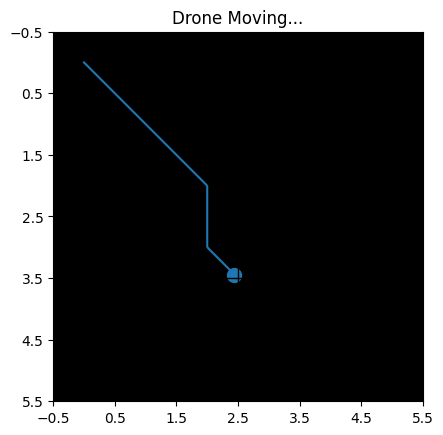

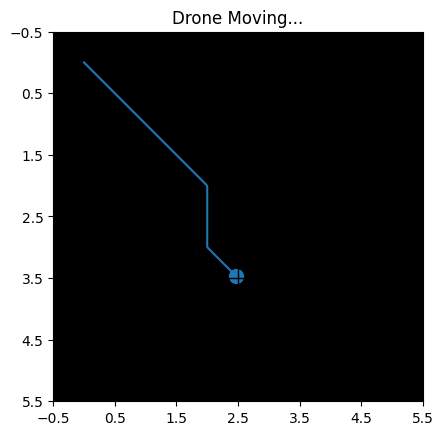

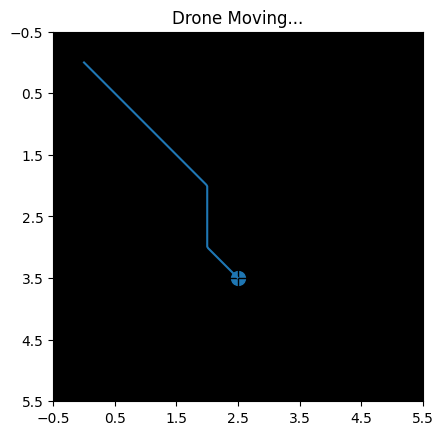

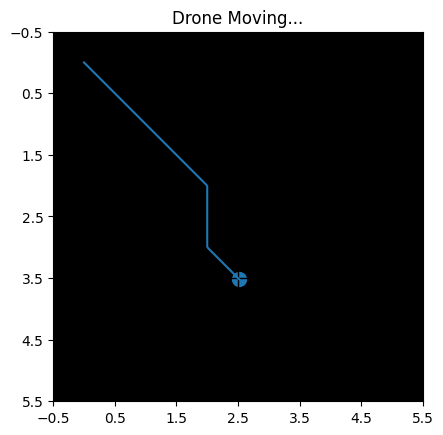

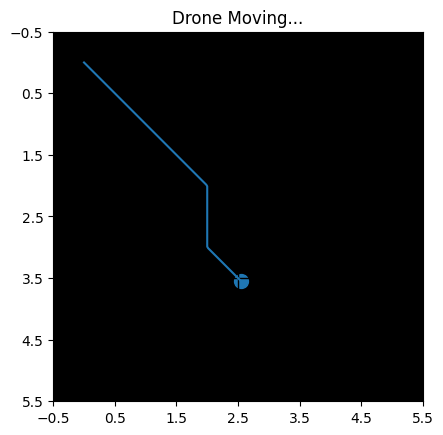

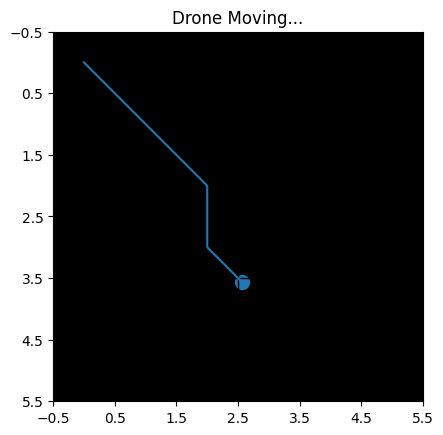

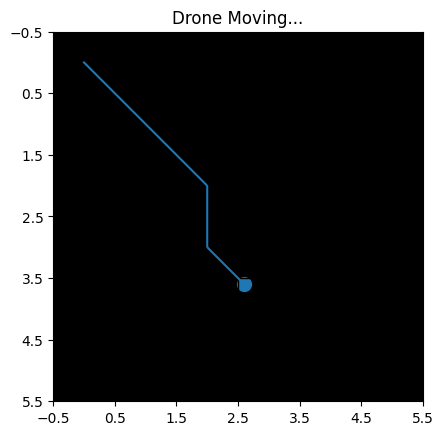

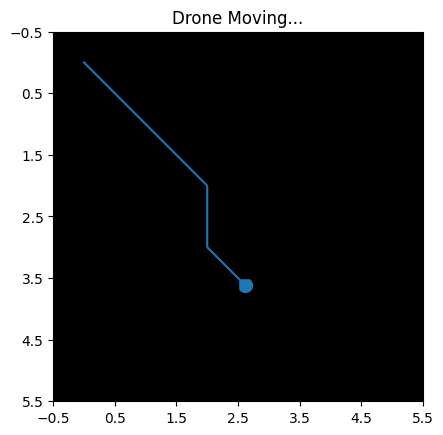

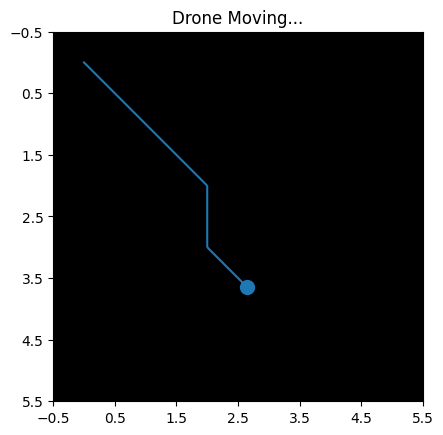

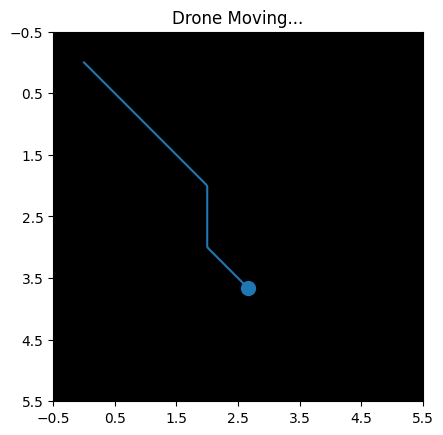

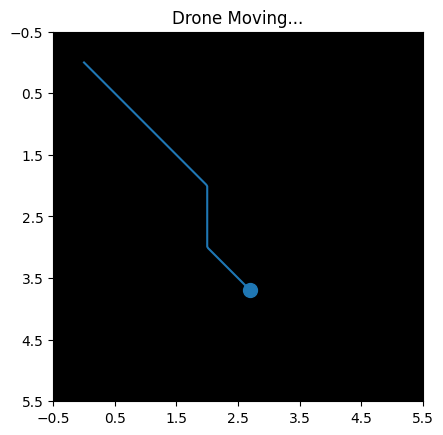

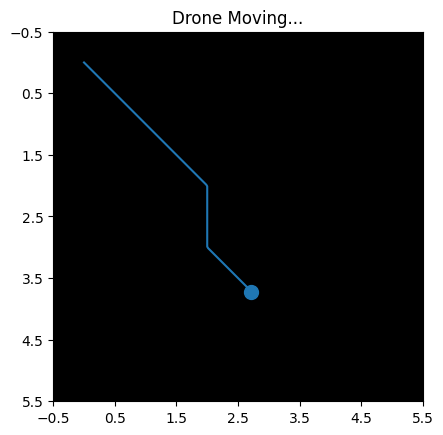

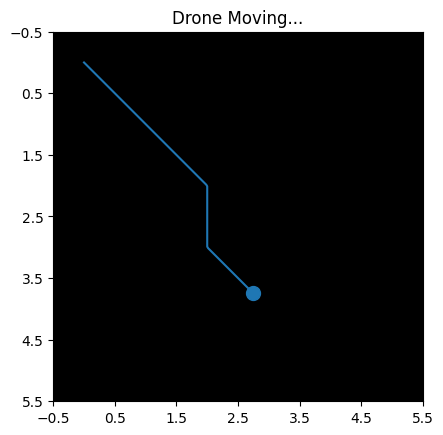

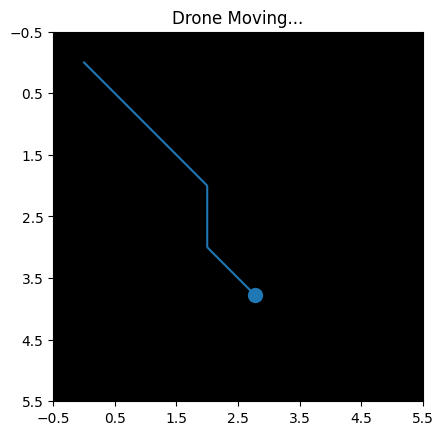

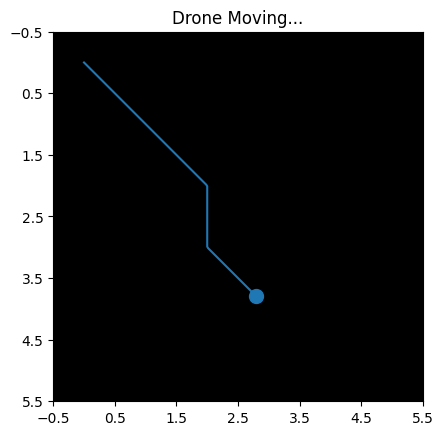

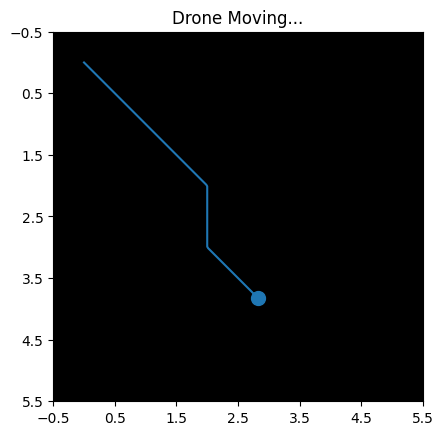

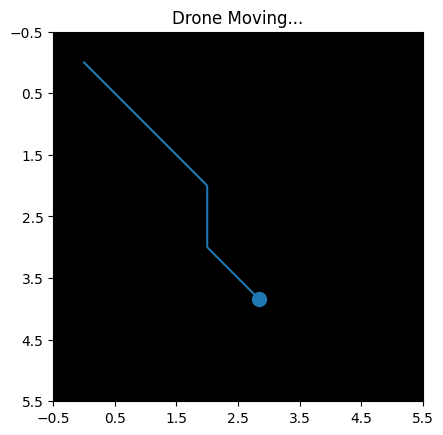

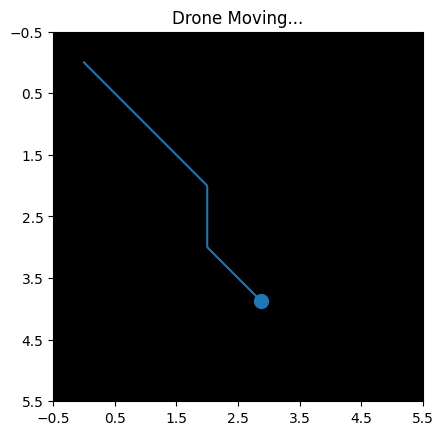

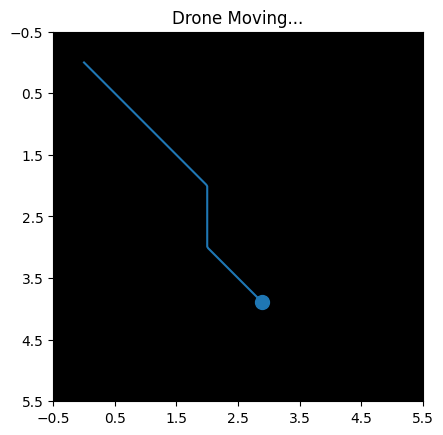

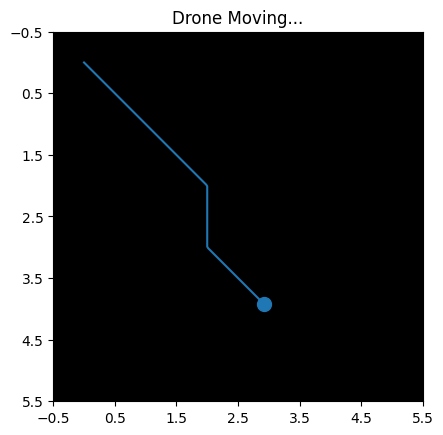

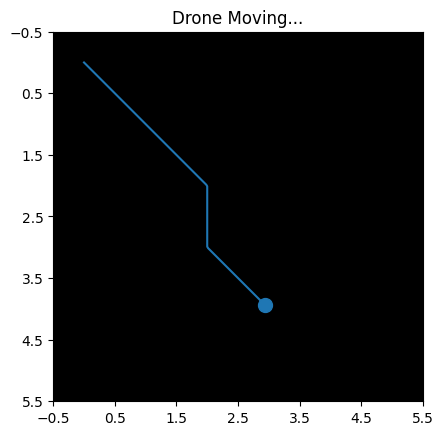

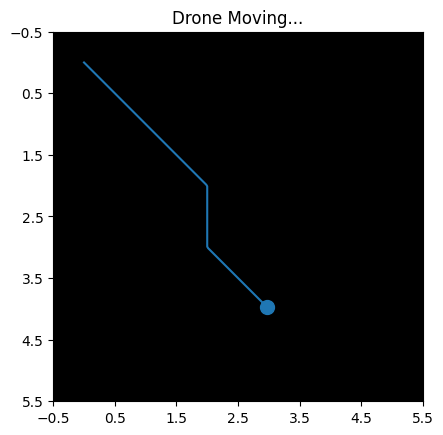

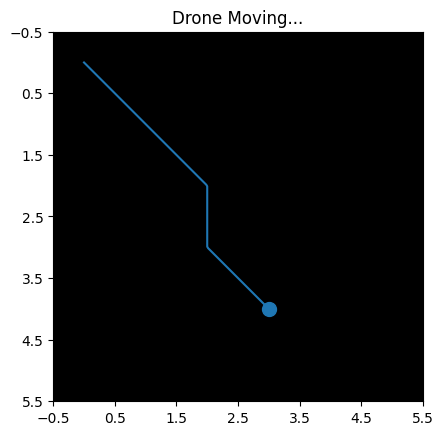

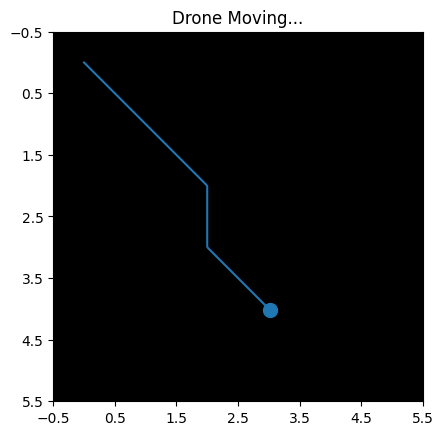

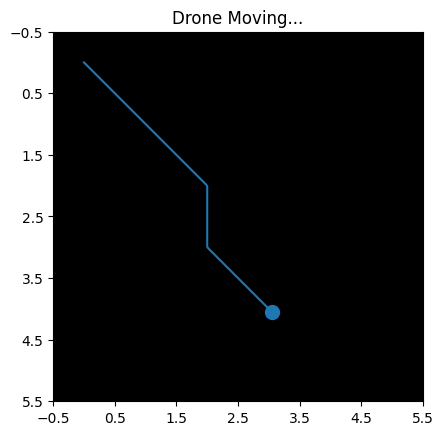

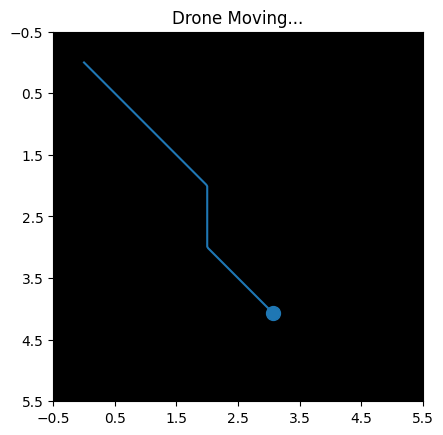

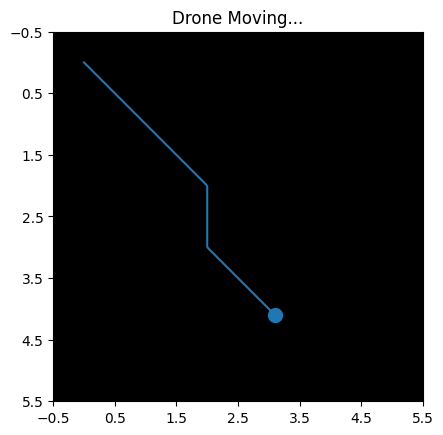

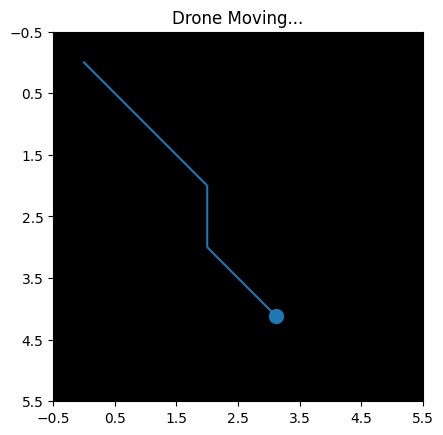

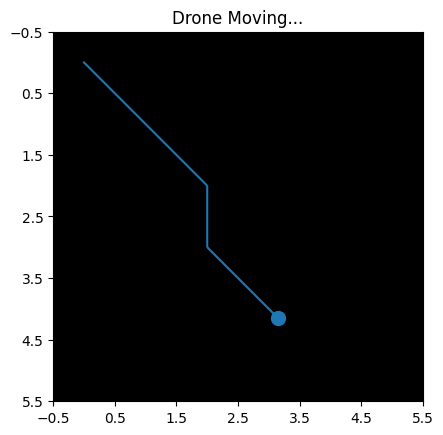

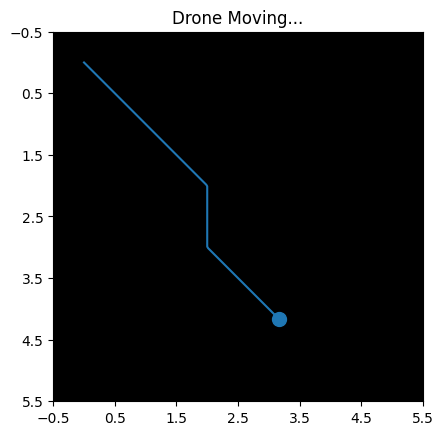

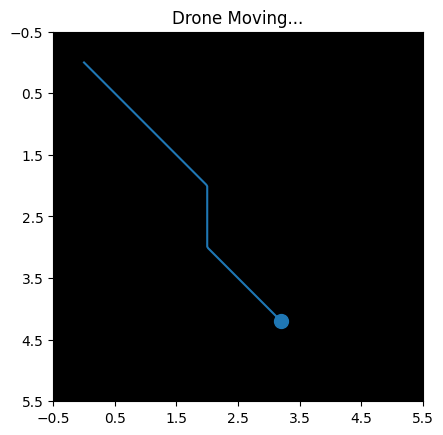

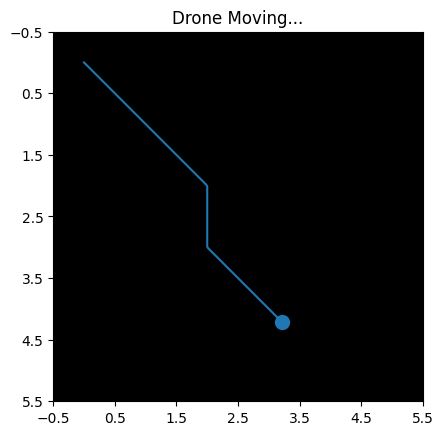

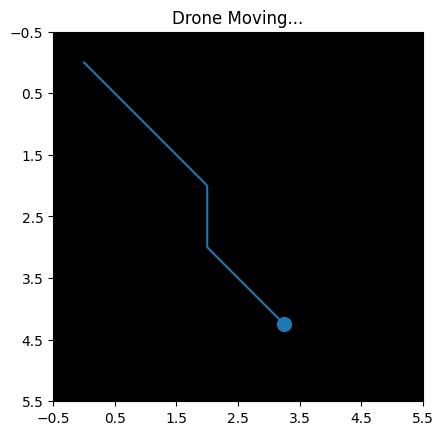

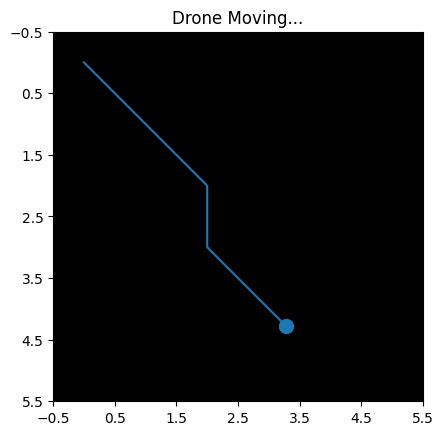

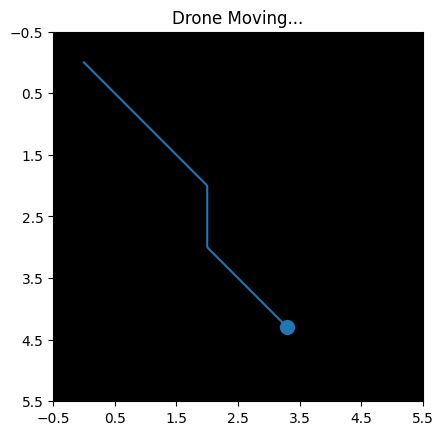

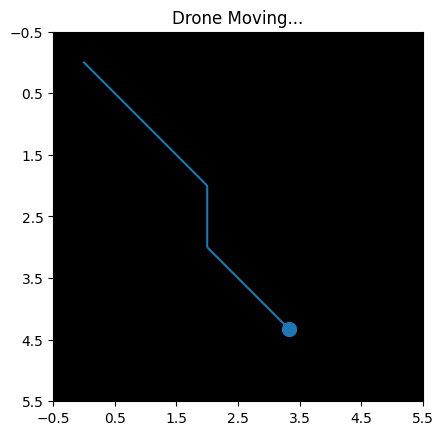

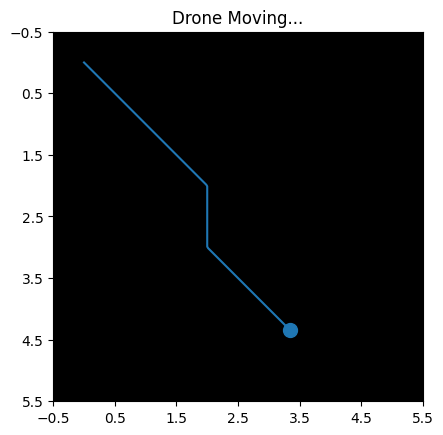

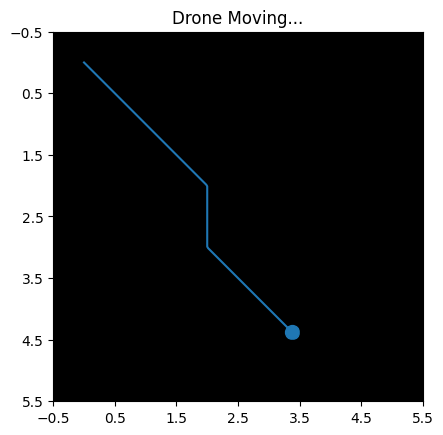

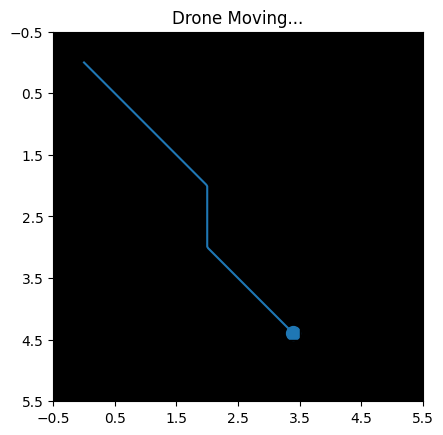

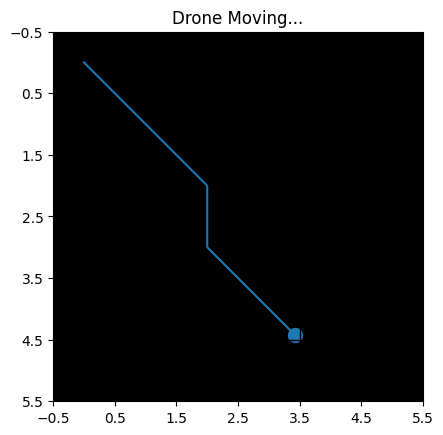

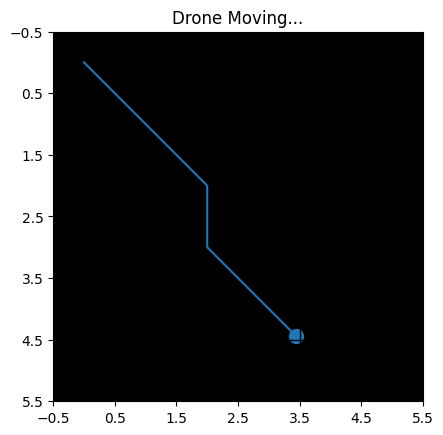

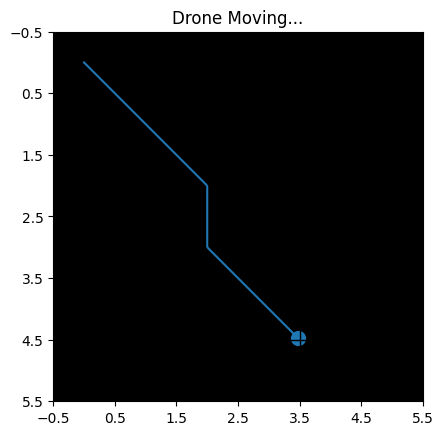

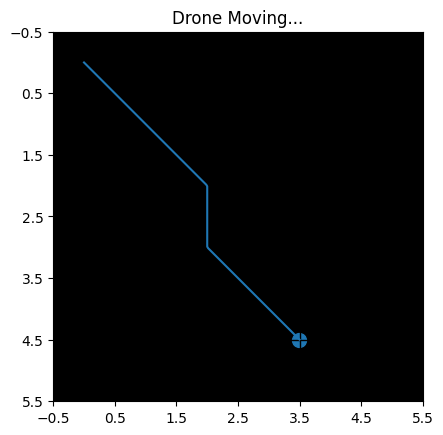

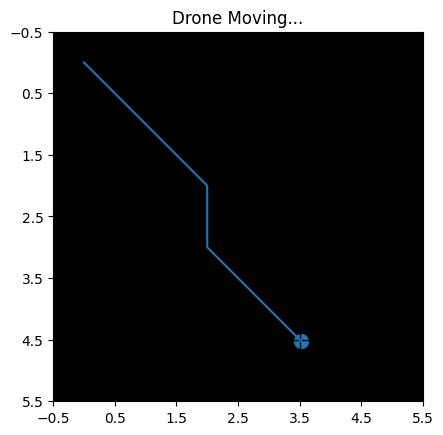

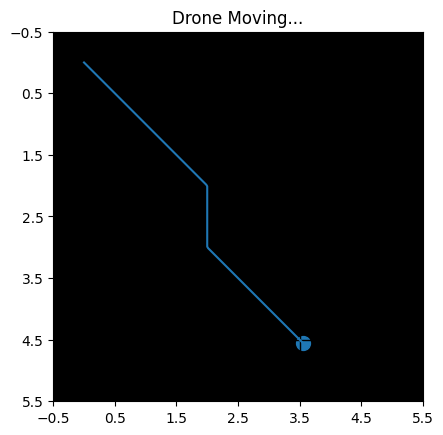

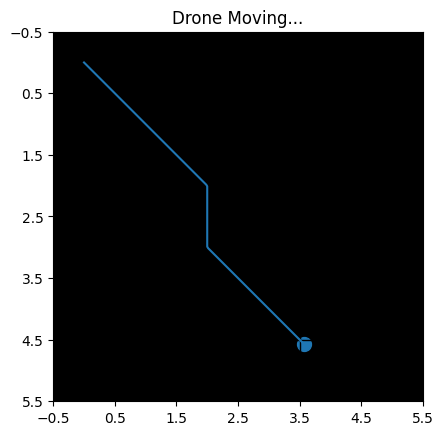

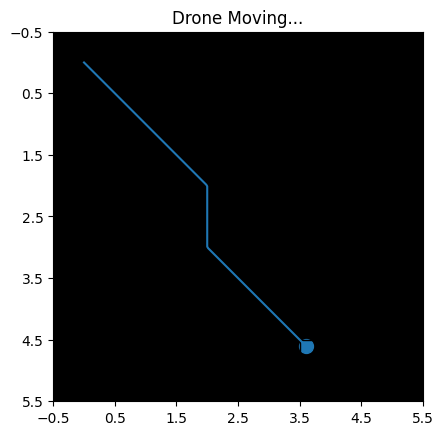

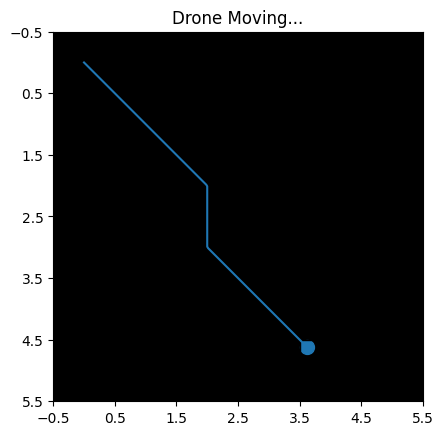

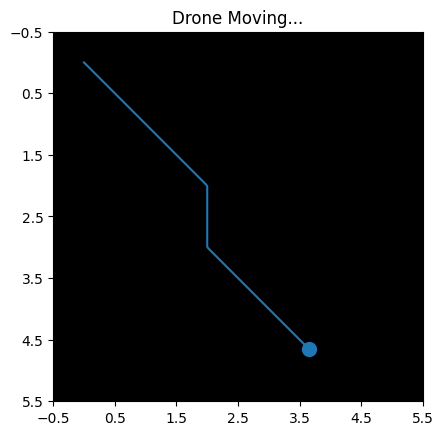

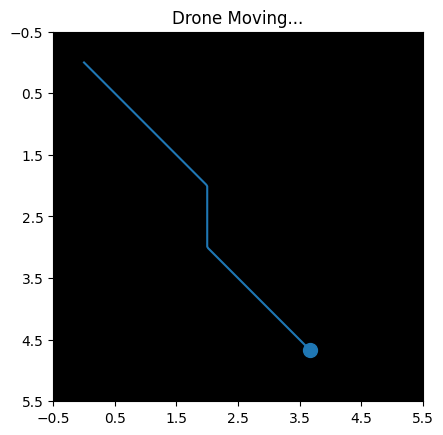

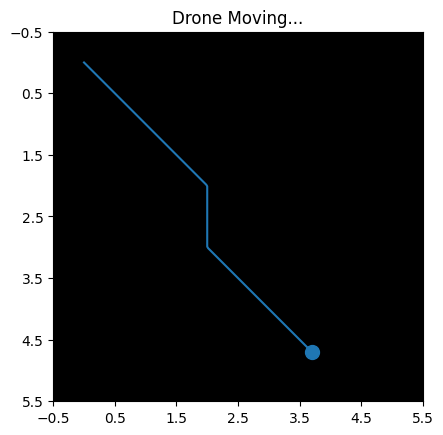

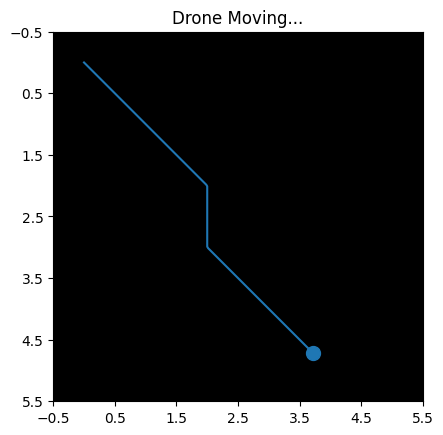

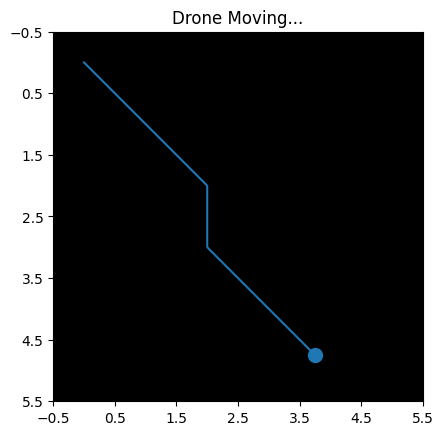

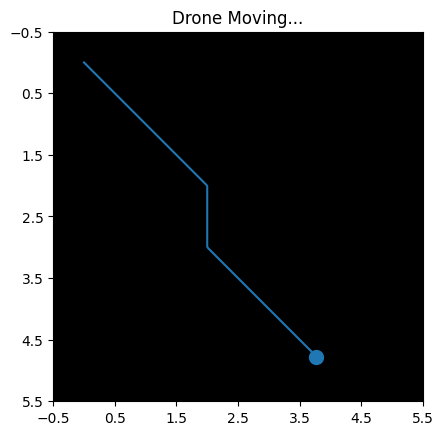

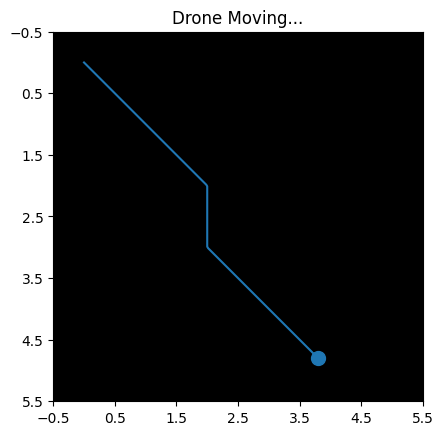

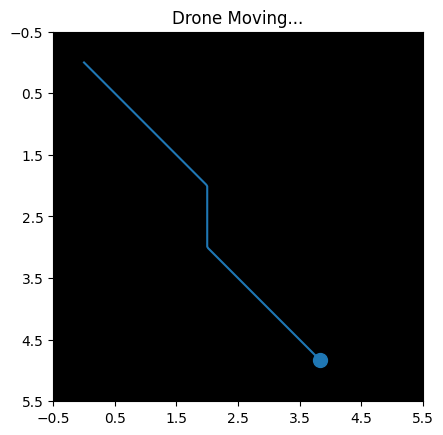

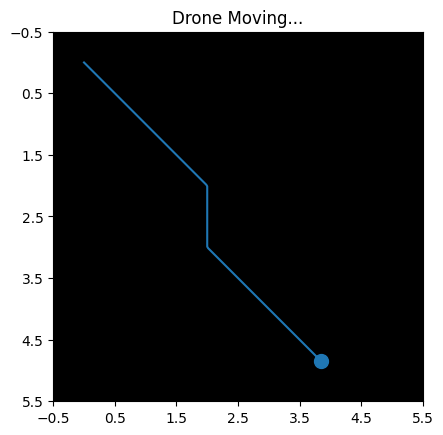

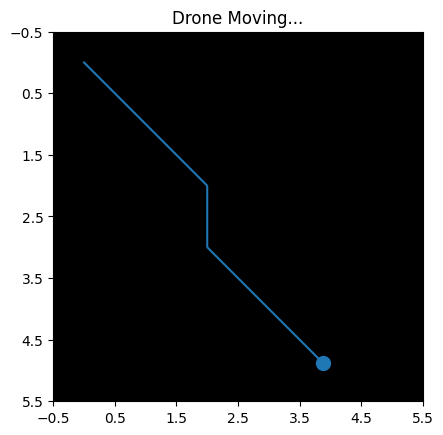

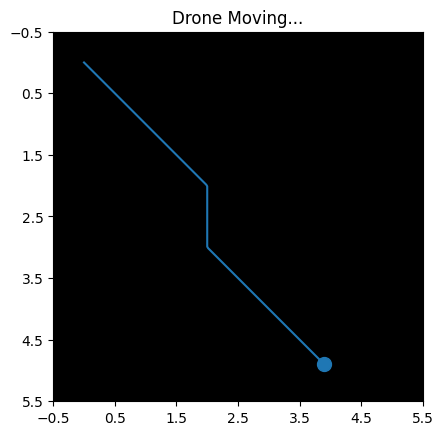

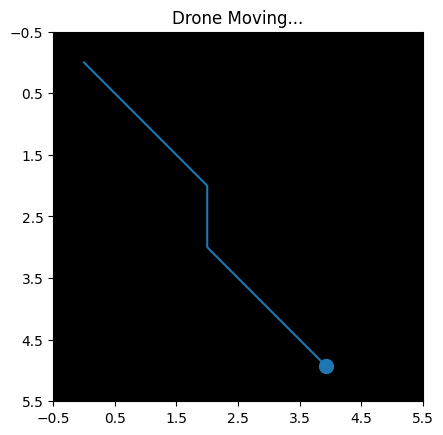

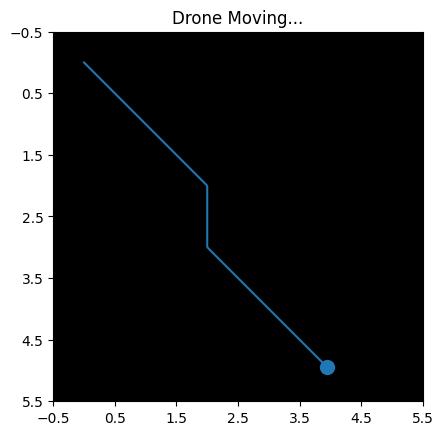

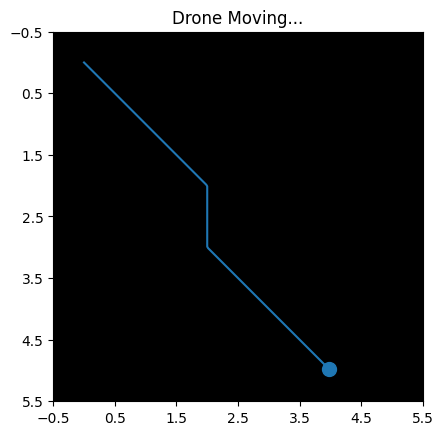

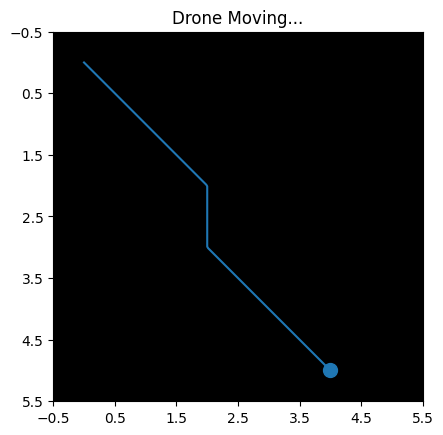

In [ ]:
import heapq
import numpy as np
import math
import matplotlib.pyplot as plt

# -----------------------------
# GRID (0 = free, 1 = obstacle)
# -----------------------------
# grid = np.array([
#     [0, 0, 0, 0, 1, 0, 0],
#     [0, 1, 0, 1, 1, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0],
#     [1, 0, 1, 1, 0, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0]
# ])

# start = (0, 0)
# goal = (4, 6)

# grid = np.zeros((7,7), dtype=int)

# start = (0, 0)
# goal  = (6, 4)


# grid = np.array([
#     [0,0,0,0,0,0,0],
#     [0,1,0,0,0,0,0],
#     [0,0,1,0,0,0,0],
#     [0,0,0,1,0,0,0],
#     [0,0,0,0,1,0,0],
#     [0,0,0,0,0,1,0],
#     [0,0,0,0,0,0,0]
# ])

# start = (0,0)
# goal  = (6,6)



# grid = np.array([
#     [0,1,0,0,0,0,0],
#     [0,1,0,1,1,1,0],
#     [0,0,0,1,0,0,0],
#     [1,1,0,1,0,1,0],
#     [0,0,0,0,0,1,0],
#     [0,1,1,1,0,0,0],
#     [0,0,0,0,0,1,0]
# ])

# start = (0,0)
# goal  = (6,6)



# grid = np.array([
#     [0,0,0,0,0,0,0],
#     [1,1,1,1,0,1,1],
#     [0,0,0,0,0,0,0],
#     [0,1,1,1,1,1,0],
#     [0,0,0,0,0,0,0]
# ])

# start = (0,0)
# goal  = (4,6)



# grid = np.array([
#     [0,0,1,0,0,0,0],
#     [0,1,1,0,1,1,0],
#     [0,0,0,0,0,1,0],
#     [1,0,1,1,0,0,0],
#     [0,0,0,1,0,1,0],
#     [0,1,0,0,0,0,0],
#     [0,0,0,1,1,0,0]
# ])

# start = (0,0)
# goal  = (6,6)



grid = np.zeros((6,6), dtype=int)

start = (0,0)
goal  = (5,4)



# -----------------------------
# HYBRID HEURISTIC
# -----------------------------
def hybrid_distance(a, b, alpha=0.1, beta=0.9):
    dx = abs(a[0] - b[0])
    dy = abs(a[1] - b[1])

    manhattan = dx + dy
    euclidean = math.sqrt(dx*dx + dy*dy)

    return alpha * manhattan + beta * euclidean


# -----------------------------
# GET NEIGHBORS (8 directions)
# -----------------------------
def get_neighbors(grid, node):
    x, y = node

    directions = [
        (1, 0), (-1, 0), (0, 1), (0, -1),
        (1, 1), (1, -1), (-1, 1), (-1, -1)
    ]

    neighbors = []

    for dx, dy in directions:
        nx, ny = x + dx, y + dy

        if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
            if grid[nx][ny] == 0:

                # Prevent corner cutting
                if abs(dx) == 1 and abs(dy) == 1:
                    if grid[x+dx][y] == 1 or grid[x][y+dy] == 1:
                        continue

                cost = 1.3 if dx != 0 and dy != 0 else 1
                neighbors.append(((nx, ny), cost))

    return neighbors


# -----------------------------
# A* ALGORITHM (FIXED)
# -----------------------------
def astar(start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    g_cost = {start: 0}
    closed_set = set()

    while open_list:
        current = heapq.heappop(open_list)

        if current in closed_set:
            continue

        closed_set.add(current)

        if current == goal:
            break

        for neighbor, move_cost in get_neighbors(grid, current):
            if neighbor in closed_set:
                continue

            new_g = g_cost[current] + move_cost

            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g

                # f = new_g + hybrid_distance(neighbor, goal)

                dx = abs(goal[0] - neighbor[0])
                dy = abs(goal[1] - neighbor[1])

                diagonal_bonus = min(dx, dy) * 0.05

                f = new_g + hybrid_distance(neighbor, goal) - diagonal_bonus

                heapq.heappush(open_list, (f, neighbor))

                came_from[neighbor] = current

    # -----------------------------
    # SAFE PATH RECONSTRUCTION
    # -----------------------------
    path = []
    node = goal

    if node not in came_from:
        print("❌ No path found!")
        return [start]

    while node != start:
        path.append(node)
        node = came_from[node]

    path.append(start)
    path.reverse()

    return path

##ADDED FOR SMOOTH PATH
def smooth_path(path, num_points=100):
    path = np.array(path)

    x = path[:, 0]
    y = path[:, 1]

    t = np.linspace(0, 1, len(path))
    t_smooth = np.linspace(0, 1, num_points)

    x_smooth = np.interp(t_smooth, t, x)
    y_smooth = np.interp(t_smooth, t, y)

    return list(zip(x_smooth, y_smooth))


# -----------------------------
# VISUALIZATION (FIXED)
# -----------------------------
# def visualize(grid, path, start, goal):
#     plt.figure(figsize=(6,6))

#     plt.imshow(grid, cmap='gray', origin='upper')

#     # grid lines
#     plt.xticks(np.arange(0, grid.shape[1], 1))
#     plt.yticks(np.arange(0, grid.shape[0], 1))
#     plt.grid(color='black', linestyle='-', linewidth=1)

#     # plot path
#     if len(path) > 1:
#         y = [p[1] for p in path]
#         x = [p[0] for p in path]
#         plt.plot(y, x, linewidth=2)

#     # start & goal
#     plt.scatter(start[1], start[0], s=100)
#     plt.scatter(goal[1], goal[0], s=100)

#     plt.title("A* Path (Hybrid Heuristic)")
#     plt.show()


###VISUALIZATION UPDATED FOR SMOOTH PATH

def visualize_smooth(grid, path, start, goal):
    plt.figure(figsize=(6,6))

    plt.imshow(grid, cmap='gray', origin='upper')

    # grid lines
    plt.xticks(np.arange(-.5, grid.shape[1], 1))
    plt.yticks(np.arange(-.5, grid.shape[0], 1))
    plt.grid(color='black', linestyle='-', linewidth=1)

    # original path
    y = [p[1] for p in path]
    x = [p[0] for p in path]
    plt.plot(y, x, linestyle='--', label="Grid Path")

    # smooth path
    smooth = smooth_path(path)
    y_s = [p[1] for p in smooth]
    x_s = [p[0] for p in smooth]

    plt.plot(y_s, x_s, linewidth=2, label="Smooth Path")

    # true straight line (reference)
    plt.plot([start[1], goal[1]], [start[0], goal[0]],
             linestyle=':', label="Ideal Line")

    # start & goal
    plt.scatter(start[1], start[0], s=100)
    plt.scatter(goal[1], goal[0], s=100)

    plt.legend()
    plt.title("Smooth Drone Path vs Grid Path")
    plt.show()


###DRONE ANIMATION

def animate_drone(grid, path):
    smooth = smooth_path(path, num_points=200)

    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap='gray', origin='upper')

    plt.xticks(np.arange(-.5, grid.shape[1], 1))
    plt.yticks(np.arange(-.5, grid.shape[0], 1))
    plt.grid(color='black', linestyle='-', linewidth=1)

    for i in range(len(smooth)):
        plt.cla()
        plt.imshow(grid, cmap='gray', origin='upper')

        plt.xticks(np.arange(-.5, grid.shape[1], 1))
        plt.yticks(np.arange(-.5, grid.shape[0], 1))
        plt.grid(color='black', linestyle='-', linewidth=1)

        # draw full path
        y_s = [p[1] for p in smooth[:i+1]]
        x_s = [p[0] for p in smooth[:i+1]]
        plt.plot(y_s, x_s)

        # drone position
        x, y = smooth[i]
        plt.scatter(y, x, s=100)

        plt.title("Drone Moving...")
        plt.pause(0.02)

    plt.show()


def bresenham_line(start, goal):
    x1, y1 = start
    x2, y2 = goal

    points = []

    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    sx = 1 if x2 > x1 else -1
    sy = 1 if y2 > y1 else -1

    err = dx - dy

    x, y = x1, y1

    while True:
        points.append((x, y))

        if (x, y) == (x2, y2):
            break

        e2 = 2 * err

        if e2 > -dy:
            err -= dy
            x += sx

        if e2 < dx:
            err += dx
            y += sy

    return points


def is_path_clear(grid, path):
    for (x, y) in path:
        if grid[x][y] == 1:
            return False
    return True


# -----------------------------
# SMART PATH (MAIN LOGIC)
# -----------------------------
def smart_path(grid, start, goal):
    if start == goal:
        return [start]

    straight_path = bresenham_line(start, goal)

    if is_path_clear(grid, straight_path):
        print("✅ Using Straight Line Path")
        return straight_path
    else:
        print("⚠️ Obstacle detected → Using A*")
        return astar(start, goal)


# -----------------------------
# RUN
# -----------------------------
# path = astar(start, goal)

# print("Path:", path)
# print("Path length:", len(path))

# visualize(grid, path, start, goal)


###UPDATED RN FUNCTION FOR SMOOTH PATH
path = smart_path(grid, start, goal)

print("Path:", path)

visualize_smooth(grid, path, start, goal)
animate_drone(grid, path)

**THIS IS THE FINAL OPTIMISED CODE WITH CURVED PATH . NO UNNECESSARY MOVEMENT IN ZIGZAG . THE DRONE WILL NOW MOVE AS IF IT IS BEING DRIVEN BY A PERSON. A PERSON WILL FL A DRONE IN CURVE PATH , NOT IN A WAY THAT INSTEAD OF MOVINIG THE DRONE IN HIPOTENUSE DIRECTION , MOVE IT IN BASE DIRECTION AND THEN IN HEIGHT DIRECTION.**

✅ Using Straight Line Path
Path: [(0, 0), (2, 2), (3, 2), (5, 4)]


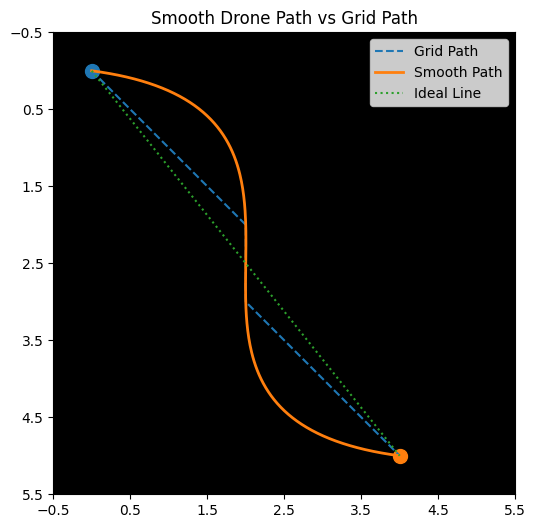

In [ ]:
import heapq
import numpy as np
import math
import matplotlib.pyplot as plt

# -----------------------------
# GRID (0 = free, 1 = obstacle)
# -----------------------------
# grid = np.array([
#     [0, 0, 0, 0, 1, 0, 0],
#     [0, 1, 0, 1, 1, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0],
#     [1, 0, 1, 1, 0, 0, 0],
#     [0, 0, 0, 0, 0, 1, 0]
# ])

# start = (0, 0)
# goal = (4, 6)

# grid = np.zeros((7,7), dtype=int)

# start = (0, 0)
# goal  = (6, 4)


# grid = np.array([
#     [0,0,0,0,0,0,0],
#     [0,1,0,0,0,0,0],
#     [0,0,1,0,0,0,0],
#     [0,0,0,1,0,0,0],
#     [0,0,0,0,1,0,0],
#     [0,0,0,0,0,1,0],
#     [0,0,0,0,0,0,0]
# ])

# start = (0,0)
# goal  = (6,6)



# grid = np.array([
#     [0,1,0,0,0,0,0],
#     [0,1,0,1,1,1,0],
#     [0,0,0,1,0,0,0],
#     [1,1,0,1,0,1,0],
#     [0,0,0,0,0,1,0],
#     [0,1,1,1,0,0,0],
#     [0,0,0,0,0,1,0]
# ])

# start = (0,0)
# goal  = (6,6)



# grid = np.array([
#     [0,0,0,0,0,0,0],
#     [1,1,1,1,0,1,1],
#     [0,0,0,0,0,0,0],
#     [0,1,1,1,1,1,0],
#     [0,0,0,0,0,0,0]
# ])

# start = (0,0)
# goal  = (4,6)



# grid = np.array([
#     [0,0,1,0,0,0,0],
#     [0,1,1,0,1,1,0],
#     [0,0,0,0,0,1,0],
#     [1,0,1,1,0,0,0],
#     [0,0,0,1,0,1,0],
#     [0,1,0,0,0,0,0],
#     [0,0,0,1,1,0,0]
# ])

# start = (0,0)
# goal  = (6,6)



grid = np.zeros((6,6), dtype=int)

start = (0,0)
goal  = (5,4)



# -----------------------------
# HYBRID HEURISTIC
# -----------------------------
def hybrid_distance(a, b, alpha=0.1, beta=0.9):
    dx = abs(a[0] - b[0])
    dy = abs(a[1] - b[1])

    manhattan = dx + dy
    euclidean = math.sqrt(dx*dx + dy*dy)

    return alpha * manhattan + beta * euclidean


# -----------------------------
# GET NEIGHBORS (8 directions)
# -----------------------------
def get_neighbors(grid, node):
    x, y = node

    directions = [
        (1, 0), (-1, 0), (0, 1), (0, -1),
        (1, 1), (1, -1), (-1, 1), (-1, -1)
    ]

    neighbors = []

    for dx, dy in directions:
        nx, ny = x + dx, y + dy

        if 0 <= nx < grid.shape[0] and 0 <= ny < grid.shape[1]:
            if grid[nx][ny] == 0:

                # Prevent corner cutting
                if abs(dx) == 1 and abs(dy) == 1:
                    if grid[x+dx][y] == 1 or grid[x][y+dy] == 1:
                        continue

                cost = 1.3 if dx != 0 and dy != 0 else 1
                neighbors.append(((nx, ny), cost))

    return neighbors


# -----------------------------
# A* ALGORITHM (FIXED)
# -----------------------------
def astar(start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    g_cost = {start: 0}
    closed_set = set()

    while open_list:
        f_score, current = heapq.heappop(open_list)

        # Use current node as tuple, not (f_score, node) tuple
        # Also, check if already processed (can happen with duplicates in open_list)
        if current in closed_set:
            continue

        closed_set.add(current)

        if current == goal:
            break

        for neighbor, move_cost in get_neighbors(grid, current):
            if neighbor in closed_set:
                continue

            new_g = g_cost[current] + move_cost

            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g

                # f = new_g + hybrid_distance(neighbor, goal)

                dx = abs(goal[0] - neighbor[0])
                dy = abs(goal[1] - neighbor[1])

                diagonal_bonus = min(dx, dy) * 0.05

                f = new_g + hybrid_distance(neighbor, goal) - diagonal_bonus

                heapq.heappush(open_list, (f, neighbor))

                came_from[neighbor] = current

    # -----------------------------
    # SAFE PATH RECONSTRUCTION
    # -----------------------------
    path = []
    node = goal

    if node not in came_from:
        print("❌ No path found!")
        return [start]

    while node != start:
        path.append(node)
        node = came_from[node]

    path.append(start)
    path.reverse()

    return path


def prune_path(path):
    pruned = [path[0]]

    for i in range(1, len(path)-1):
        prev = pruned[-1]
        curr = path[i]
        next = path[i+1]

        # Check if direction changes
        if (curr[0]-prev[0], curr[1]-prev[1]) != (next[0]-curr[0], next[1]-curr[1]):
            pruned.append(curr)

    pruned.append(path[-1])
    return pruned


##ADDED FOR SMOOTH PATH (THID ONE IS DIFFERENT FROM THE PREVIOUS ONE)
from scipy.interpolate import splprep, splev

def smooth_path(path, num_points=200):
    path = np.array(path)

    x = path[:, 0]
    y = path[:, 1]

    # Create spline
    tck, u = splprep([x, y], s=2)

    u_new = np.linspace(0, 1, num_points)
    x_smooth, y_smooth = splev(u_new, tck)

    return list(zip(x_smooth, y_smooth))


# -----------------------------
# VISUALIZATION (FIXED)
# -----------------------------
# def visualize(grid, path, start, goal):
#     plt.figure(figsize=(6,6))

#     plt.imshow(grid, cmap='gray', origin='upper')

#     # grid lines
#     plt.xticks(np.arange(0, grid.shape[1], 1))
#     plt.yticks(np.arange(0, grid.shape[0], 1))
#     plt.grid(color='black', linestyle='-', linewidth=1)

#     # plot path
#     if len(path) > 1:
#         y = [p[1] for p in path]
#         x = [p[0] for p in path]
#         plt.plot(y, x, linewidth=2)

#     # start & goal
#     plt.scatter(start[1], start[0], s=100)
#     plt.scatter(goal[1], goal[0], s=100)

#     plt.title("A* Path (Hybrid Heuristic)")
#     plt.show()


###VISUALIZATION UPDATED FOR SMOOTH PATH

def visualize_smooth(grid, path, start, goal):
    plt.figure(figsize=(6,6))

    plt.imshow(grid, cmap='gray', origin='upper')

    # grid lines
    plt.xticks(np.arange(-.5, grid.shape[1], 1))
    plt.yticks(np.arange(-.5, grid.shape[0], 1))
    plt.grid(color='black', linestyle='-', linewidth=1)

    # original path
    y = [p[1] for p in path]
    x = [p[0] for p in path]
    plt.plot(y, x, linestyle='--', label="Grid Path")

    # smooth path
    smooth = smooth_path(path)
    y_s = [p[1] for p in smooth]
    x_s = [p[0] for p in smooth]

    plt.plot(y_s, x_s, linewidth=2, label="Smooth Path")

    # true straight line (reference)
    plt.plot([start[1], goal[1]], [start[0], goal[0]],
             linestyle=':', label="Ideal Line")

    # start & goal
    plt.scatter(start[1], start[0], s=100)
    plt.scatter(goal[1], goal[0], s=100)

    plt.legend()
    plt.title("Smooth Drone Path vs Grid Path")
    plt.show()


###DRONE ANIMATION

def animate_drone(grid, path):
    smooth = smooth_path(path, num_points=200)

    plt.figure(figsize=(6,6))
    plt.imshow(grid, cmap='gray', origin='upper')

    plt.xticks(np.arange(-.5, grid.shape[1], 1))
    plt.yticks(np.arange(-.5, grid.shape[0], 1))
    plt.grid(color='black', linestyle='-', linewidth=1)

    for i in range(len(smooth)):
        plt.cla()
        plt.imshow(grid, cmap='gray', origin='upper')

        plt.xticks(np.arange(-.5, grid.shape[1], 1))
        plt.yticks(np.arange(-.5, grid.shape[0], 1))
        plt.grid(color='black', linestyle='-', linewidth=1)

        # draw full path
        y_s = [p[1] for p in smooth[:i+1]]
        x_s = [p[0] for p in smooth[:i+1]]
        plt.plot(y_s, x_s)

        # drone position
        x, y = smooth[i]
        plt.scatter(y, x, s=100)

        plt.title("Drone Moving...")
        plt.pause(0.02)

    plt.show()


def bresenham_line(start, goal):
    x1, y1 = start
    x2, y2 = goal

    points = []

    dx = abs(x2 - x1)
    dy = abs(y2 - y1)

    sx = 1 if x2 > x1 else -1
    sy = 1 if y2 > y1 else -1

    err = dx - dy

    x, y = x1, y1

    while True:
        points.append((x, y))

        if (x, y) == (x2, y2):
            break

        e2 = 2 * err

        if e2 > -dy:
            err -= dy
            x += sx

        if e2 < dx:
            err += dx
            y += sy

    return points


def is_path_clear(grid, path):
    for (x, y) in path:
        # Check if the coordinates are within the grid bounds before accessing grid[x][y]
        if not (0 <= x < grid.shape[0] and 0 <= y < grid.shape[1]):
            return False # Path goes out of bounds, thus not clear
        if grid[x][y] == 1:
            return False
    return True


# -----------------------------
# SMART PATH (MAIN LOGIC)
# -----------------------------
def smart_path(grid, start, goal):
    if start == goal:
        return [start]

    straight_path = bresenham_line(start, goal)

    if is_path_clear(grid, straight_path):
        print("✅ Using Straight Line Path")
        return straight_path
    else:
        print("⚠️ Obstacle detected → Using A*")
        return astar(start, goal)


# -----------------------------
# RUN
# -----------------------------
# path = astar(start, goal)

# print("Path:", path)
# print("Path length:", len(path))

# visualize(grid, path, start, goal)


###UPDATED RN FUNCTION FOR SMOOTH PATH
path = smart_path(grid, start, goal)

# Only prune the path if it's not a single point (i.e., if a path was found and it's longer than just the start)
if path and len(path) > 1:
    path = prune_path(path)

print("Path:", path)

visualize_smooth(grid, path, start, goal)
#animate_drone(grid, path)


**Note** = in the above code , animate function can be commented out to remove the unnecessary results frames per second.

**Problem inabove code :** It is not working for the grids defined above in the code. The is working well for "
grid = np.zeros((6,6), dtype=int)

start = (0,0)
goal  = (5,4)
"

but not for the grids defined with 0s and 1s.

**OPTIMIZE IT LATER**